
===== MULTI-SESSION GLOBAL FIRING RATE OVERVIEW =====

--- 03-03: 2026-03-03_10-26-01_experiment1_recording1_analysis ---
  Good units: 40, Noise units: 40
  Recording duration: 2262.2 s (37.7 min)

--- 03-04: 2026-03-04_08-31-33_experiment1_recording1_analysis ---
  Good units: 100, Noise units: 100
  Recording duration: 2447.3 s (40.8 min)

--- 03-05: 2026-03-05_09-27-03_experiment2_recording1_analysis ---
  Good units: 192, Noise units: 192
  Recording duration: 3729.4 s (62.2 min)

--- 03-09: 2026-03-09_14-29-25_experiment2_recording1_analysis ---
  Good units: 185, Noise units: 185
  Recording duration: 1992.2 s (33.2 min)

--- 03-10: 2026-03-10_13-58-34_experiment1_recording1_analysis ---
  Good units: 87, Noise units: 87
  Recording duration: 1285.0 s (21.4 min)


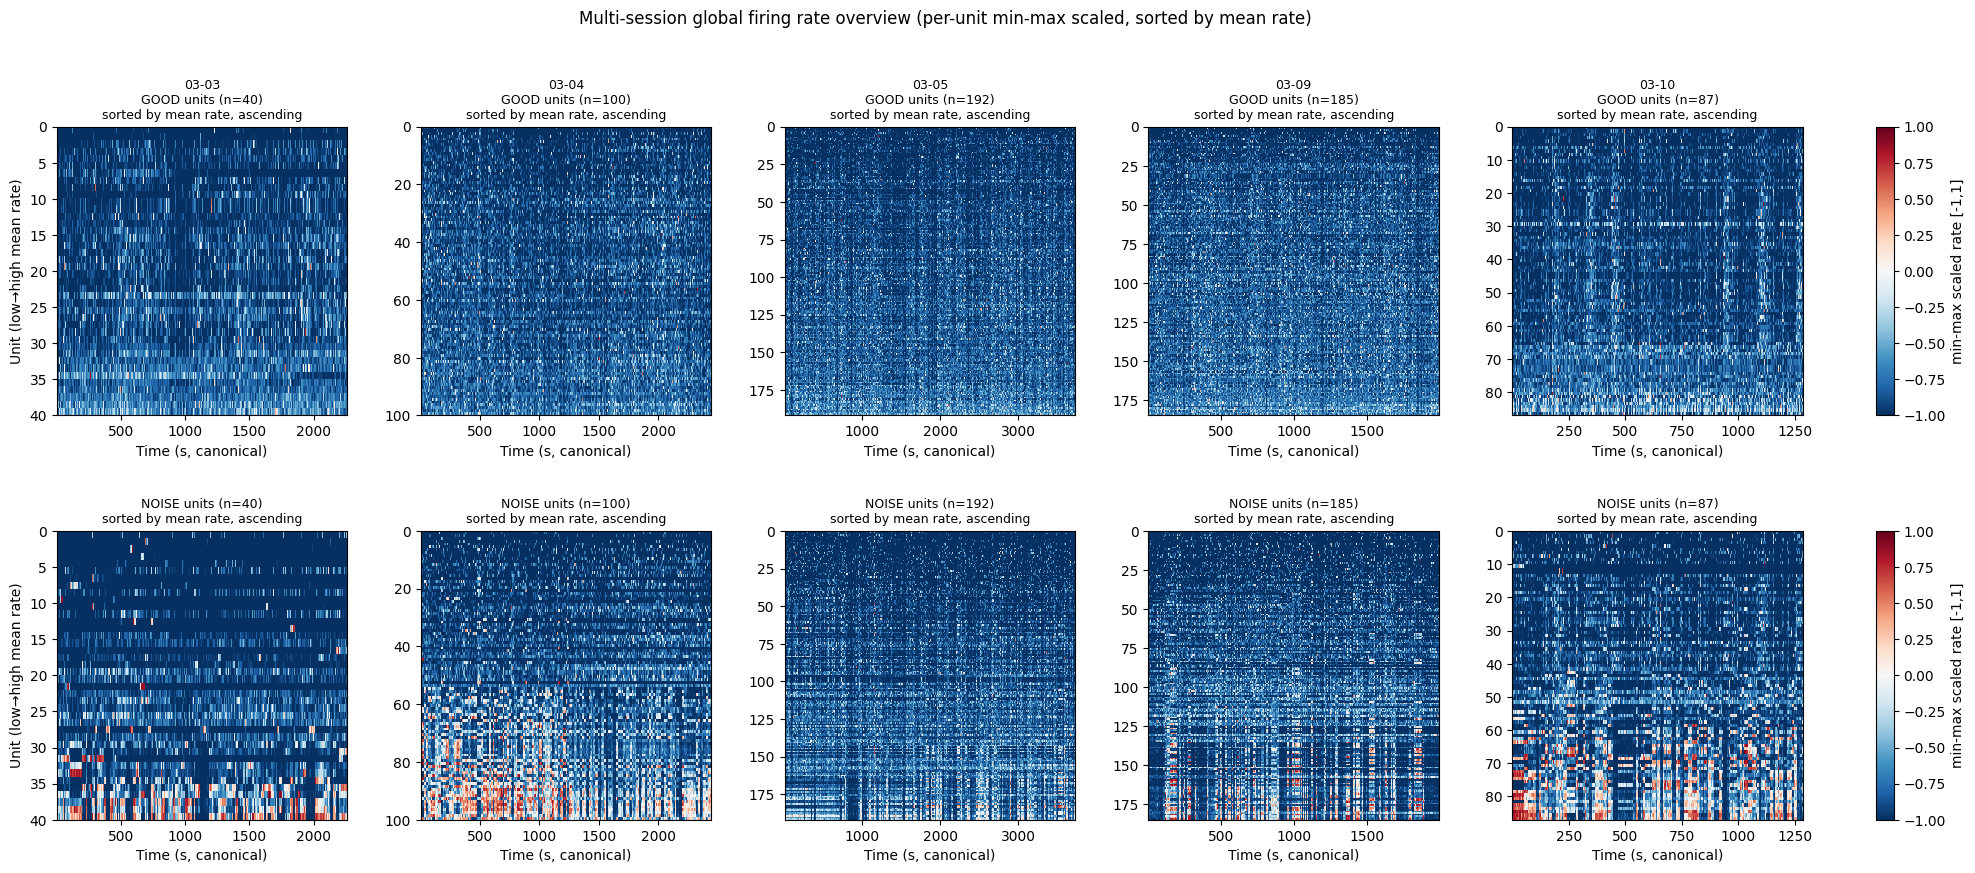


===== SESSION SUMMARY =====
Session   N_good  N_noise  Dur(min)  GoodMeanHz  NoiseMeanHz
03-03         40       40      37.7        0.25         0.56
03-04        100      100      40.8        0.23         1.12
03-05        192      192      62.2        0.24         0.43
03-09        185      185      33.2        0.30         0.57
03-10         87       87      21.4        0.27         0.96

===== DONE =====


In [1]:
# ============================================================
# CELL — MULTI-SESSION GLOBAL FIRING RATE OVERVIEW
# ============================================================
# Loads precomputed rate_matrix/centers/good_units/noise_units
# from each session's qc/ folder (already built by Cell A — no
# new spike-time computation happens here).
#
# DATA-SHAPING DECISIONS MADE IN THIS CELL (read before trusting plots):
#   1. NORMALIZATION: each unit's rate trace is min-max scaled to
#      [-1, 1] independently. This is a per-unit rescaling — it
#      preserves the SHAPE of each unit's rate over time but
#      deliberately discards absolute firing rate differences
#      between units. A unit that fires at 1 Hz and one that fires
#      at 50 Hz will look visually identical in dynamic range.
#      This is necessary to avoid high-rate units visually
#      dominating the plot, but it is a real transformation of
#      the data, not a neutral display choice.
#   2. SORTING: units are sorted by their MEAN FIRING RATE across
#      the whole session (low to high). This is intentionally NOT
#      based on any behavioral event, task structure, or response
#      property — it's the most "neutral" ordering available, but
#      note that mean rate itself is influenced by recording
#      quality/yield per session, so cross-session row N does NOT
#      correspond to the "same" unit or even the same relative
#      rank reliably — sorting is recomputed independently per
#      session/panel.
#   3. NO unit selection/filtering beyond what Cell A already did
#      (Cell A's MIN_BASELINE_HZ-style filtering, if any, is
#      inherited as-is; this cell does not add additional inclusion
#      criteria of its own).
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== MULTI-SESSION GLOBAL FIRING RATE OVERVIEW =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
}
# ------------------------------------------------------------

def minmax_scale_rows(mat):
    """Per-row min-max scale to [-1, 1]. Rows with zero variance
    (e.g. a silent unit) are returned as all-zero rather than NaN."""
    mn = mat.min(axis=1, keepdims=True)
    mx = mat.max(axis=1, keepdims=True)
    rng = mx - mn
    rng[rng == 0] = 1.0  # avoid div-by-zero; result will be 0 for flat rows
    return 2 * (mat - mn) / rng - 1

n_sessions = len(SESSION_FOLDERS)

# ------------------------------------------------------------
# FIGURE LAYOUT — dedicated colorbar columns, no tight_layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(4.5 * n_sessions + 1.2, 9))
gs = fig.add_gridspec(2, n_sessions + 1,
                      width_ratios=[1] * n_sessions + [0.06],
                      wspace=0.3, hspace=0.4)

axes = np.empty((2, n_sessions), dtype=object)
for row in range(2):
    for col in range(n_sessions):
        axes[row, col] = fig.add_subplot(gs[row, col])

cax_good  = fig.add_subplot(gs[0, n_sessions])
cax_noise = fig.add_subplot(gs[1, n_sessions])

session_summary = []
im, im2 = None, None

for col, (label, folder) in enumerate(SESSION_FOLDERS.items()):
    folder = Path(folder)
    print(f"\n--- {label}: {folder.name} ---")

    centers     = np.load(folder / "qc" / "centers.npy")
    rate_matrix = np.load(folder / "qc" / "rate_matrix.npy")
    good_units  = np.load(folder / "qc" / "good_units.npy")
    noise_units = np.load(folder / "qc" / "noise_units.npy")
    noise_rate  = np.load(folder / "qc" / "noise_rate_matrix.npy")

    print(f"  Good units: {len(good_units)}, Noise units: {len(noise_units)}")
    print(f"  Recording duration: {centers[-1]:.1f} s "
          f"({centers[-1]/60:.1f} min)")

    # SORT: by mean firing rate, ascending. Independent per panel.
    good_mean_rate  = rate_matrix.mean(axis=1)
    noise_mean_rate = noise_rate.mean(axis=1)
    good_order  = np.argsort(good_mean_rate)
    noise_order = np.argsort(noise_mean_rate)

    # NORMALIZE: per-unit min-max to [-1, 1]
    good_scaled  = minmax_scale_rows(rate_matrix[good_order])
    noise_scaled = minmax_scale_rows(noise_rate[noise_order])

    # Good units (top row)
    ax = axes[0, col]
    im = ax.imshow(good_scaled, aspect="auto",
                   extent=[centers[0], centers[-1], len(good_units), 0],
                   cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"{label}\nGOOD units (n={len(good_units)})\n"
                 f"sorted by mean rate, ascending", fontsize=9)
    ax.set_xlabel("Time (s, canonical)")
    if col == 0:
        ax.set_ylabel("Unit (low→high mean rate)")

    # Noise units (bottom row)
    ax = axes[1, col]
    im2 = ax.imshow(noise_scaled, aspect="auto",
                    extent=[centers[0], centers[-1], len(noise_units), 0],
                    cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"NOISE units (n={len(noise_units)})\n"
                 f"sorted by mean rate, ascending", fontsize=9)
    ax.set_xlabel("Time (s, canonical)")
    if col == 0:
        ax.set_ylabel("Unit (low→high mean rate)")

    session_summary.append({
        "label": label,
        "n_good": int(len(good_units)),
        "n_noise": int(len(noise_units)),
        "duration_min": float(centers[-1] / 60),
        "good_mean_rate_hz": float(good_mean_rate.mean()),
        "noise_mean_rate_hz": float(noise_mean_rate.mean()),
    })

# Dedicated colorbars — no longer competing with data panels for space
fig.colorbar(im,  cax=cax_good,  label="min-max scaled rate [-1,1]")
fig.colorbar(im2, cax=cax_noise, label="min-max scaled rate [-1,1]")

plt.suptitle("Multi-session global firing rate overview "
            "(per-unit min-max scaled, sorted by mean rate)",
            fontsize=12, y=1.01)
# NOTE: tight_layout() is intentionally NOT called — the gridspec
# above already defines explicit spacing including the colorbar
# columns, and tight_layout() conflicts with that, which was the
# source of both the UserWarning and the colorbar-over-data overlap
# you saw previously.
plt.show()

print("\n===== SESSION SUMMARY =====")
print(f"{'Session':<8} {'N_good':>7} {'N_noise':>8} {'Dur(min)':>9} "
      f"{'GoodMeanHz':>11} {'NoiseMeanHz':>12}")
for s in session_summary:
    print(f"{s['label']:<8} {s['n_good']:>7} {s['n_noise']:>8} "
          f"{s['duration_min']:>9.1f} {s['good_mean_rate_hz']:>11.2f} "
          f"{s['noise_mean_rate_hz']:>12.2f}")

print("\n===== DONE =====")


===== MULTI-SESSION PETH (AMPLITUDE-SORTED, WIDE-WINDOW NORMALIZED) =====

--- 03-03: 2026-03-03_10-26-01_experiment1_recording1_analysis ---
  Events on pin 4 (tone): 55

--- 03-04: 2026-03-04_08-31-33_experiment1_recording1_analysis ---
  Events on pin 4 (tone): 71

--- 03-05: 2026-03-05_09-27-03_experiment2_recording1_analysis ---
  Events on pin 4 (tone): 87

--- 03-09: 2026-03-09_14-29-25_experiment2_recording1_analysis ---
  Events on pin 4 (tone): 48

--- 03-10: 2026-03-10_13-58-34_experiment1_recording1_analysis ---
  Events on pin 4 (tone): 35


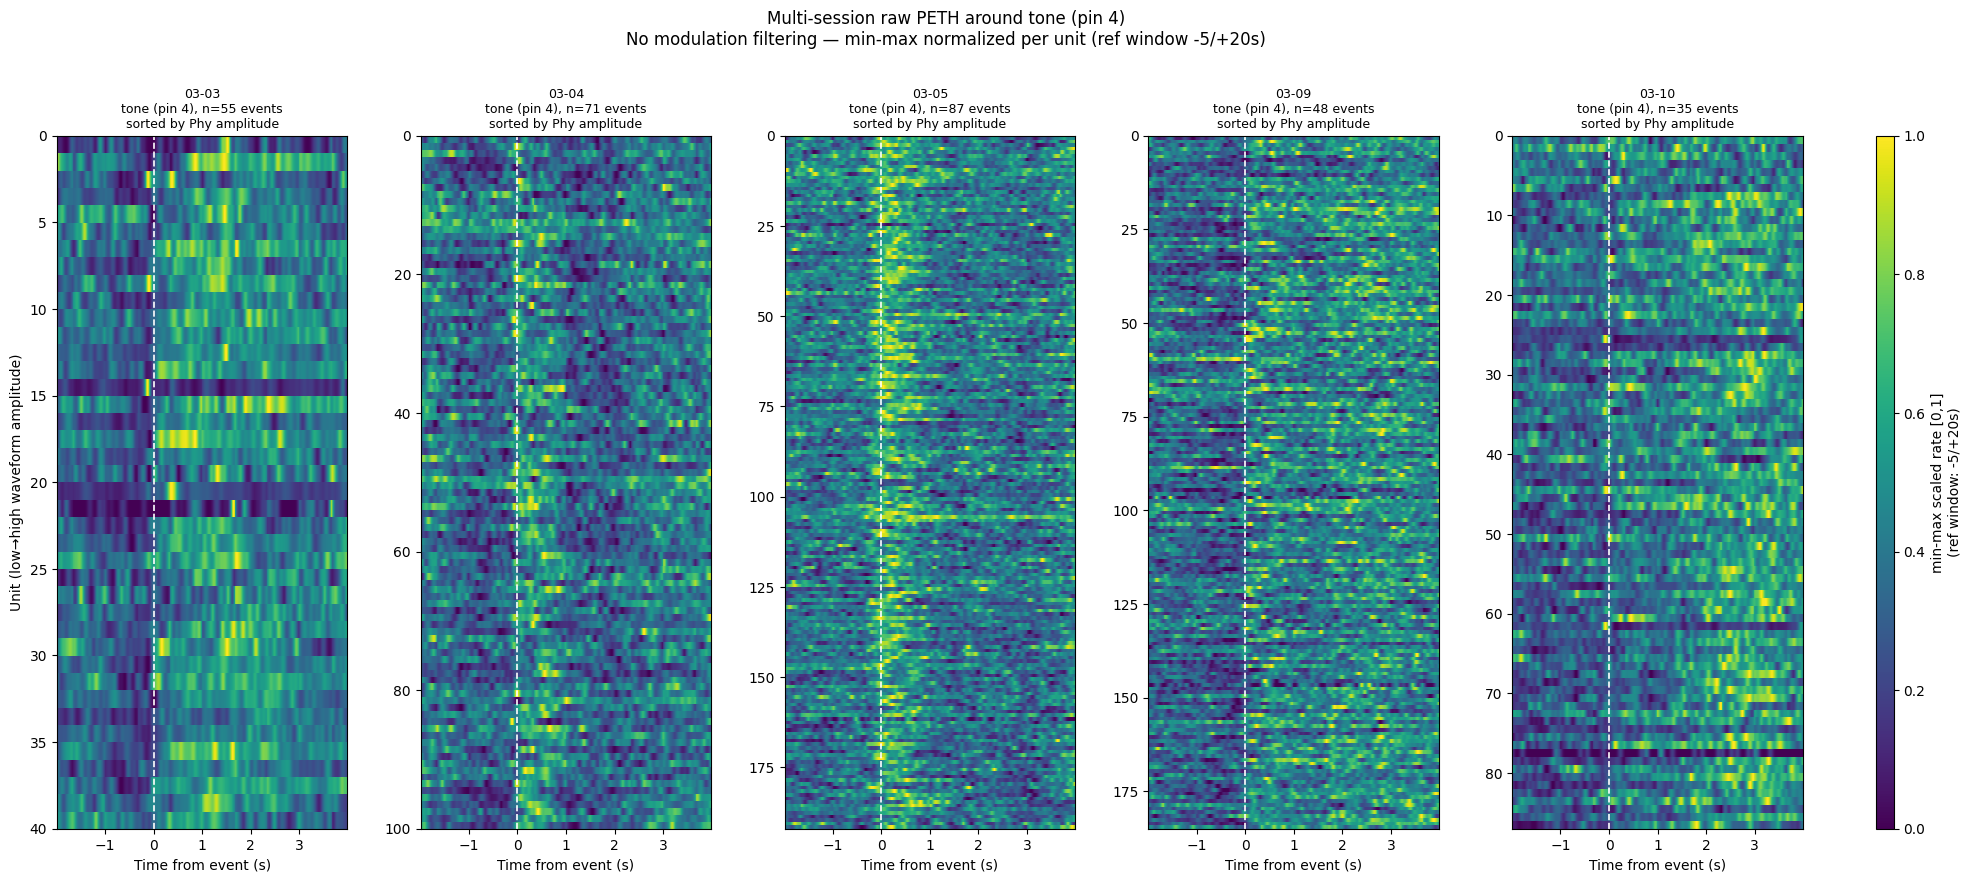


===== SESSION SUMMARY =====
03-03    units=  40  events=   55  missing_amp=0
03-04    units= 100  events=   71  missing_amp=0
03-05    units= 192  events=   87  missing_amp=0
03-09    units= 185  events=   48  missing_amp=0
03-10    units=  87  events=   35  missing_amp=0

===== DONE =====


In [3]:
# ============================================================
# CELL — MULTI-SESSION PETH AROUND TTL EVENT (AMPLITUDE-SORTED)
# ============================================================
# Computes a simple peri-event firing rate (NOT z-scored, NOT
# modulation-tested) for every good unit, aligned to a chosen
# TTL pin, for each session. Units are sorted by Phy waveform
# amplitude — a property that has nothing to do with the
# behavioral response itself, keeping the sort "neutral" with
# respect to the question of modulation.
#
# DATA-SHAPING DECISIONS MADE IN THIS CELL:
#   1. NO modulation threshold or statistical testing of any kind.
#      This is still the rawest possible peri-event TIMING view.
#   2. NORMALIZATION (IMPORTANT — READ THIS): each unit's color
#      scale is min-max computed over a WIDE REFERENCE WINDOW
#      (NORM_WIN_PRE to NORM_WIN_POST, e.g. -5 to +20s relative to
#      the event), NOT the narrower window that is actually
#      displayed (WIN_PRE to WIN_POST, e.g. -2 to +4s). This
#      decouples "what range stretches the colors" from "what time
#      range is shown." The reference window deliberately spans
#      the full behavioral episode (cue through the end of the
#      reach opportunity), so a unit's color scale reflects its
#      real dynamic range across that whole episode — a flat/
#      unresponsive unit will now look uniformly dim rather than
#      showing an artificial "hot spot," which was the problem
#      with normalizing only over the displayed window. Using this
#      episode-scoped reference window (rather than the whole
#      session) is itself a choice: it keeps normalization tied to
#      "cue-to-reach-opportunity" dynamics specifically, which
#      matters for later comparing this plot against a reach-
#      aligned version using the same reference window logic.
#   3. SORTING by Phy "amp" column (cluster_info.tsv) — a
#      hardware/spike-sorting property, NOT a behavioral or
#      response property.
#   4. EVENT SELECTION: by default ALL rising edges on the chosen
#      pin are used. For pin 3 (motor), this includes BOTH expose
#      and retract edges unless EVENT_PIN_3_HALF is set.
#   5. SMOOTHING: a Gaussian kernel is applied before normalization
#      for visual clarity (blurs single-bin sharpness).
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== MULTI-SESSION PETH (AMPLITUDE-SORTED, WIDE-WINDOW NORMALIZED) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
}

KILOSORT_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4",
}

EVENT_PIN          = 4      # 4=tone, 3=motor (both expose+retract), 6=IR beam, 7=button
EVENT_PIN_3_HALF   = None   # if EVENT_PIN==3: "expose" ([0::2]) or "retract" ([1::2]); None = both

# DISPLAY window — what you actually see on the x-axis
WIN_PRE             = 2.0
WIN_POST            = 4.0

# NORMALIZATION reference window — used ONLY to compute each unit's
# min/max for color scaling. Independent of the display window above.
NORM_WIN_PRE        = 5.0
NORM_WIN_POST       = 20.0   # full reach-opportunity window

BIN_SIZE            = 0.020
SMOOTH_SIGMA_BINS   = 2
MAX_EVENTS_PER_SESSION = None   # None = use all events found on the pin
NORMALIZE           = True       # True = per-unit min-max (wide window); False = raw Hz
# ------------------------------------------------------------

PIN_LABELS = {0:"camera1",1:"camera2",2:"capacitance(unused)",3:"motor",
              4:"tone",5:"np_sync_1hz",6:"reach_ir_beam",7:"button"}
event_label = PIN_LABELS.get(EVENT_PIN, f"pin{EVENT_PIN}")

# Display bins (narrow window, what gets plotted)
edges_disp = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers_disp = edges_disp[:-1] + BIN_SIZE / 2

# Normalization bins (wide window, used only to compute min/max)
edges_norm = np.arange(-NORM_WIN_PRE, NORM_WIN_POST + BIN_SIZE, BIN_SIZE)
centers_norm = edges_norm[:-1] + BIN_SIZE / 2

# The display window must be a subset of the normalization window,
# otherwise min/max wouldn't include everything being shown.
if WIN_PRE > NORM_WIN_PRE or WIN_POST > NORM_WIN_POST:
    raise ValueError("Display window must fit within the normalization "
                     "reference window (NORM_WIN_PRE/NORM_WIN_POST).")

def minmax_scale_with_reference(display_mat, ref_mat):
    """Scale display_mat to [0,1] using min/max computed from ref_mat,
    row-wise (per unit). Flat reference rows (no variance) -> 0."""
    mn = ref_mat.min(axis=1, keepdims=True)
    mx = ref_mat.max(axis=1, keepdims=True)
    rng = mx - mn
    rng[rng == 0] = 1.0
    return (display_mat - mn) / rng

n_sessions = len(SESSION_FOLDERS)

# ------------------------------------------------------------
# FIGURE LAYOUT — dedicated colorbar column, no tight_layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(4.5 * n_sessions + 1.2, 9))
gs = fig.add_gridspec(1, n_sessions + 1,
                      width_ratios=[1] * n_sessions + [0.06],
                      wspace=0.3)

axes = [fig.add_subplot(gs[0, col]) for col in range(n_sessions)]
cax = fig.add_subplot(gs[0, n_sessions])

session_summary = []
im = None

for col, label in enumerate(SESSION_FOLDERS):
    folder = Path(SESSION_FOLDERS[label])
    ks_folder = Path(KILOSORT_FOLDERS[label])
    print(f"\n--- {label}: {folder.name} ---")

    good_units = np.load(folder / "qc" / "good_units.npy")
    spikes_dir = folder / "spikes"

    # Load Phy amplitude for sorting
    cluster_info = pd.read_csv(ks_folder / "cluster_info.tsv", sep="\t")
    amp_lookup = dict(zip(cluster_info["id"], cluster_info["amp"]))
    amps = np.array([amp_lookup.get(int(u), np.nan) for u in good_units])
    n_missing_amp = int(np.isnan(amps).sum())
    if n_missing_amp:
        print(f"  WARNING: {n_missing_amp} good units missing 'amp' in "
              f"cluster_info.tsv — placed at the end of the sort.")
    amp_order = np.argsort(np.where(np.isnan(amps), np.inf, amps))

    # Load event times for this pin
    event_times = np.load(folder / "ttls" / f"TTL_Pin_{EVENT_PIN}.npy")
    this_label = event_label
    if EVENT_PIN == 3 and EVENT_PIN_3_HALF is not None:
        if EVENT_PIN_3_HALF == "expose":
            event_times = event_times[0::2]; this_label = "motor_expose"
        elif EVENT_PIN_3_HALF == "retract":
            event_times = event_times[1::2]; this_label = "motor_retract"
    if MAX_EVENTS_PER_SESSION is not None:
        event_times = event_times[:MAX_EVENTS_PER_SESSION]
    print(f"  Events on pin {EVENT_PIN} ({this_label}): {len(event_times)}")

    # ---- Trial-averaged PETH over the WIDE reference window ----
    # (computed once; the narrow display window is just a slice of it)
    peth_wide = np.zeros((len(good_units), len(centers_norm)))
    for u_i, u in enumerate(good_units):
        spk = np.load(spikes_dir / f"unit_{u}.npy")
        trial_hists = np.zeros((len(event_times), len(centers_norm)))
        for e_i, t_evt in enumerate(event_times):
            rel = spk[(spk >= t_evt - NORM_WIN_PRE) & (spk < t_evt + NORM_WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges_norm)
            trial_hists[e_i] = h / BIN_SIZE
        peth_wide[u_i] = trial_hists.mean(axis=0)
    peth_wide_smooth = gaussian_filter1d(peth_wide, sigma=SMOOTH_SIGMA_BINS, axis=1)

    # ---- Slice out the narrow display window from the wide array ----
    disp_mask = (centers_norm >= -WIN_PRE) & (centers_norm < WIN_POST)
    peth_disp_smooth = peth_wide_smooth[:, disp_mask]

    peth_wide_sorted = peth_wide_smooth[amp_order]
    peth_disp_sorted = peth_disp_smooth[amp_order]

    if NORMALIZE:
        # min/max from the WIDE window, applied to the NARROW display slice
        peth_display = minmax_scale_with_reference(peth_disp_sorted, peth_wide_sorted)
        vmin, vmax = 0, 1
        cbar_label = f"min-max scaled rate [0,1]\n(ref window: -{NORM_WIN_PRE:.0f}/+{NORM_WIN_POST:.0f}s)"
    else:
        peth_display = peth_disp_sorted
        vmin, vmax = 0, max(np.percentile(peth_disp_sorted, 99), 1.0)
        cbar_label = "firing rate (Hz)"

    ax = axes[col]
    im = ax.imshow(peth_display, aspect="auto",
                   extent=[centers_disp[0], centers_disp[-1], len(good_units), 0],
                   cmap="viridis", vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="white", lw=1.2, linestyle="--")
    ax.set_title(f"{label}\n{this_label} (pin {EVENT_PIN}), n={len(event_times)} events\n"
                f"sorted by Phy amplitude", fontsize=9)
    ax.set_xlabel("Time from event (s)")
    if col == 0:
        ax.set_ylabel("Unit (low→high waveform amplitude)")

    session_summary.append({
        "label": label, "n_units": int(len(good_units)),
        "n_events": int(len(event_times)), "n_missing_amp": n_missing_amp,
    })

# Dedicated colorbar — no longer competing with the last panel for space
fig.colorbar(im, cax=cax, label=cbar_label)

norm_tag = (f"min-max normalized per unit (ref window -{NORM_WIN_PRE:.0f}/+{NORM_WIN_POST:.0f}s)"
           if NORMALIZE else "raw Hz")
plt.suptitle(f"Multi-session raw PETH around {event_label} (pin {EVENT_PIN})\n"
            f"No modulation filtering — {norm_tag}",
            fontsize=12, y=1.02)
plt.show()

print("\n===== SESSION SUMMARY =====")
for s in session_summary:
    print(f"{s['label']:<8} units={s['n_units']:>4}  events={s['n_events']:>5}  "
          f"missing_amp={s['n_missing_amp']}")

print("\n===== DONE =====")


===== MULTI-SESSION REACH-ALIGNED PETH (CUE-ANCHORED NORMALIZATION) =====

--- 03-03 ---
    in_trial_first: 52 reaches, 52 with valid tone pairing
    in_trial: 106 reaches, 106 with valid tone pairing

--- 03-04 ---
    in_trial_first: 60 reaches, 60 with valid tone pairing
    in_trial: 111 reaches, 111 with valid tone pairing

--- 03-05 ---
    in_trial_first: 68 reaches, 68 with valid tone pairing
    in_trial: 112 reaches, 112 with valid tone pairing

--- 03-09 ---
    in_trial_first: 48 reaches, 48 with valid tone pairing
    in_trial: 119 reaches, 119 with valid tone pairing

--- 03-10 ---
    in_trial_first: 33 reaches, 33 with valid tone pairing
    in_trial: 66 reaches, 66 with valid tone pairing


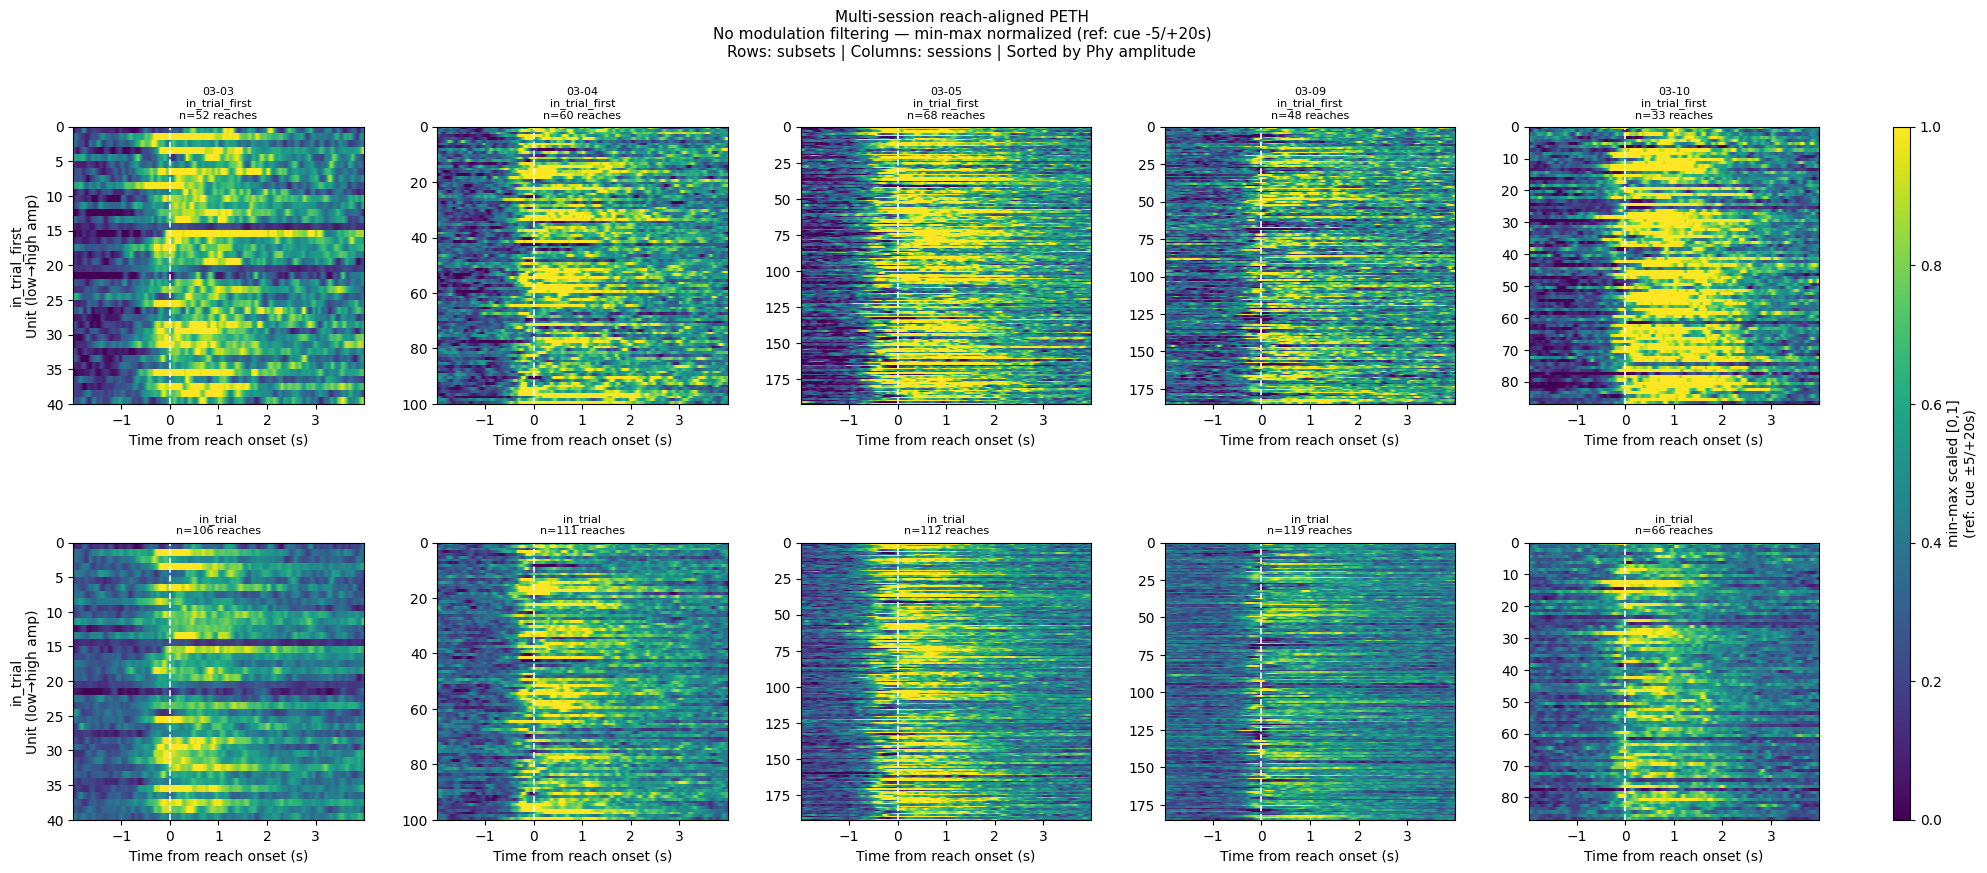


===== SESSION SUMMARY =====
Session   N_units N_in_trial_first     N_in_trial
03-03          40             52            106
03-04         100             60            111
03-05         192             68            112
03-09         185             48            119
03-10          87             33             66

===== DONE =====


In [5]:
# ============================================================
# CELL — MULTI-SESSION REACH-ALIGNED PETH (AMPLITUDE-SORTED)
#        WITH CUE-ANCHORED NORMALIZATION
# ============================================================
# Display window is centered on reach onset (DLC-derived bout
# onset), but normalization reference window is anchored to the
# tone cue (pin 4) that preceded each reach. This keeps the
# color scale comparable to the cue-aligned PETH cell, since
# both use the same -NORM_WIN_PRE/+NORM_WIN_POST window around
# the cue as their reference epoch.
#
# DATA-SHAPING DECISIONS MADE IN THIS CELL:
#   1. EVENT DEFINITION: reach onset = DLC bout onset (Cell J v3),
#      filtered by subset (in_trial / in_trial_first / beam_breaking).
#   2. NORMALIZATION ANCHOR: for each reach, the normalization
#      reference window is computed relative to the tone cue (pin 4
#      TTL) that most recently preceded that reach within the same
#      trial. Reaches with no preceding tone within MAX_CUE_LOOKBACK_S
#      seconds are excluded from normalization (rare edge case).
#      The reference PETH is trial-averaged across those cue-anchored
#      windows, then min/max is computed from that to scale the
#      reach-aligned display PETH. This ensures the color scale for
#      both the cue-aligned and reach-aligned plots reflects the same
#      behavioral episode, making them directly comparable.
#   3. SORTING: Phy waveform amplitude, same as cue-aligned cell.
#   4. Same smoothing (Gaussian, sigma=2 bins) applied to both the
#      display PETH and the normalization reference PETH.
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== MULTI-SESSION REACH-ALIGNED PETH (CUE-ANCHORED NORMALIZATION) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
}

KILOSORT_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4",
}

SUBSETS_TO_PLOT    = ["in_trial_first", "in_trial"]

TONE_PIN           = 4       # pin that marks trial cue onset

# Display window — centered on reach onset
WIN_PRE            = 2.0
WIN_POST           = 4.0

# Normalization reference window — centered on the TONE CUE
# preceding each reach. Keep identical to cue-aligned cell.
NORM_WIN_PRE       = 5.0
NORM_WIN_POST      = 20.0

# Max time to look back from a reach to find its preceding tone.
# Any reach with no tone within this window is excluded from the
# normalization PETH (but still included in the display PETH).
MAX_CUE_LOOKBACK_S = 25.0

BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
NORMALIZE          = True
# ------------------------------------------------------------

if WIN_PRE > NORM_WIN_PRE or WIN_POST > NORM_WIN_POST:
    raise ValueError("Display window must fit within the normalization window.")

def build_subset_mask(name, bout_trial_id, bout_broke_beam, bout_onset_t):
    if name == "in_trial":
        return bout_trial_id >= 0
    if name == "in_trial_first":
        m = np.zeros(len(bout_onset_t), dtype=bool)
        for t_i in np.unique(bout_trial_id):
            if t_i == -1:
                continue
            ii = np.where(bout_trial_id == t_i)[0]
            m[ii[np.argmin(bout_onset_t[ii])]] = True
        return m
    if name == "beam_breaking":
        return bout_broke_beam.astype(bool)
    raise ValueError(f"Unknown subset: {name}")

def minmax_scale_with_reference(display_mat, ref_mat):
    mn = ref_mat.min(axis=1, keepdims=True)
    mx = ref_mat.max(axis=1, keepdims=True)
    rng = mx - mn
    rng[rng == 0] = 1.0
    return (display_mat - mn) / rng

def find_preceding_tone(reach_times, tone_times, max_lookback):
    """For each reach, find the most recent tone that preceded it
    within max_lookback seconds. Returns array of tone times, one
    per reach, with np.nan where no qualifying tone was found."""
    tone_times_sorted = np.sort(tone_times)
    result = np.full(len(reach_times), np.nan)
    for i, t_reach in enumerate(reach_times):
        # tones that preceded this reach within the lookback window
        candidates = tone_times_sorted[
            (tone_times_sorted < t_reach) &
            (tone_times_sorted >= t_reach - max_lookback)
        ]
        if len(candidates):
            result[i] = candidates[-1]  # most recent preceding tone
    return result

# Bin grids
edges_norm = np.arange(-NORM_WIN_PRE, NORM_WIN_POST + BIN_SIZE, BIN_SIZE)
centers_norm = edges_norm[:-1] + BIN_SIZE / 2
edges_disp = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers_disp = edges_disp[:-1] + BIN_SIZE / 2
disp_mask = (centers_norm >= -WIN_PRE) & (centers_norm < WIN_POST)

n_rows = len(SUBSETS_TO_PLOT)
n_sessions = len(SESSION_FOLDERS)

fig = plt.figure(figsize=(4.5 * n_sessions + 1.2, 4.5 * n_rows))
gs = fig.add_gridspec(n_rows, n_sessions + 1,
                      width_ratios=[1] * n_sessions + [0.06],
                      wspace=0.3, hspace=0.5)

axes = np.empty((n_rows, n_sessions), dtype=object)
for row in range(n_rows):
    for col in range(n_sessions):
        axes[row, col] = fig.add_subplot(gs[row, col])
cax = fig.add_subplot(gs[:, n_sessions])

session_summary = []
im = None

for col, label in enumerate(SESSION_FOLDERS):
    folder = Path(SESSION_FOLDERS[label])
    ks_folder = Path(KILOSORT_FOLDERS[label])
    print(f"\n--- {label} ---")

    good_units = np.load(folder / "qc" / "good_units.npy")
    spikes_dir = folder / "spikes"

    # Phy amplitude sort order
    cluster_info = pd.read_csv(ks_folder / "cluster_info.tsv", sep="\t")
    amp_lookup = dict(zip(cluster_info["id"], cluster_info["amp"]))
    amps = np.array([amp_lookup.get(int(u), np.nan) for u in good_units])
    amp_order = np.argsort(np.where(np.isnan(amps), np.inf, amps))

    # Load bout data and tone times
    bouts = np.load(folder / "peak_detection" / "bouts.npz")
    bout_onset_t    = bouts["onset_t"]
    bout_trial_id   = bouts["trial_id"]
    bout_broke_beam = bouts["broke_beam"]
    tone_times = np.load(folder / "ttls" / f"TTL_Pin_{TONE_PIN}.npy")

    # Build per-subset event lists and their paired cue times
    subset_data = {}
    for subset_name in SUBSETS_TO_PLOT:
        mask = build_subset_mask(subset_name, bout_trial_id,
                                 bout_broke_beam, bout_onset_t)
        reach_times = np.sort(bout_onset_t[mask])
        paired_tones = find_preceding_tone(reach_times, tone_times,
                                           MAX_CUE_LOOKBACK_S)
        n_no_tone = int(np.isnan(paired_tones).sum())
        if n_no_tone:
            print(f"    {subset_name}: {n_no_tone} reaches had no preceding "
                  f"tone within {MAX_CUE_LOOKBACK_S}s — excluded from "
                  f"normalization reference only.")
        # cue times with valid tone pairing (for normalization PETH)
        valid_mask = ~np.isnan(paired_tones)
        subset_data[subset_name] = {
            "reach_times": reach_times,
            "norm_cue_times": paired_tones[valid_mask],
            "n_no_tone": n_no_tone,
        }
        print(f"    {subset_name}: {len(reach_times)} reaches, "
              f"{valid_mask.sum()} with valid tone pairing")

    # Compute PETHs per subset
    for row, subset_name in enumerate(SUBSETS_TO_PLOT):
        ax = axes[row, col]
        sd = subset_data[subset_name]
        reach_times = sd["reach_times"]
        norm_cue_times = sd["norm_cue_times"]

        if len(reach_times) < 3:
            ax.text(0.5, 0.5, f"<3 reaches\n({subset_name})",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=9, color="gray")
            if row == 0:
                ax.set_title(f"{label}\n{subset_name}\n(no data)", fontsize=8)
            else:
                ax.set_title(f"{subset_name}\n(no data)", fontsize=8)
            continue

        # ── DISPLAY PETH: reach-aligned, narrow window ──
        peth_disp = np.zeros((len(good_units), len(centers_disp)))
        for u_i, u in enumerate(good_units):
            spk = np.load(spikes_dir / f"unit_{u}.npy")
            trial_hists = np.zeros((len(reach_times), len(centers_disp)))
            for e_i, t_reach in enumerate(reach_times):
                rel = spk[(spk >= t_reach - WIN_PRE) &
                          (spk < t_reach + WIN_POST)] - t_reach
                h, _ = np.histogram(rel, bins=edges_disp)
                trial_hists[e_i] = h / BIN_SIZE
            peth_disp[u_i] = gaussian_filter1d(
                trial_hists.mean(axis=0), sigma=SMOOTH_SIGMA_BINS)

        peth_disp_sorted = peth_disp[amp_order]

        if NORMALIZE and len(norm_cue_times) >= 3:
            # ── NORMALIZATION PETH: cue-aligned, wide window ──
            peth_norm = np.zeros((len(good_units), len(centers_norm)))
            for u_i, u in enumerate(good_units):
                spk = np.load(spikes_dir / f"unit_{u}.npy")
                trial_hists = np.zeros((len(norm_cue_times), len(centers_norm)))
                for e_i, t_cue in enumerate(norm_cue_times):
                    rel = spk[(spk >= t_cue - NORM_WIN_PRE) &
                              (spk < t_cue + NORM_WIN_POST)] - t_cue
                    h, _ = np.histogram(rel, bins=edges_norm)
                    trial_hists[e_i] = h / BIN_SIZE
                peth_norm[u_i] = gaussian_filter1d(
                    trial_hists.mean(axis=0), sigma=SMOOTH_SIGMA_BINS)

            peth_norm_sorted = peth_norm[amp_order]
            peth_display = minmax_scale_with_reference(
                peth_disp_sorted, peth_norm_sorted)
            vmin, vmax = 0, 1
            cbar_label = (f"min-max scaled [0,1]\n"
                         f"(ref: cue ±{NORM_WIN_PRE:.0f}/+{NORM_WIN_POST:.0f}s)")
        else:
            peth_display = peth_disp_sorted
            vmin = 0
            vmax = max(np.percentile(peth_disp_sorted, 99), 1.0)
            cbar_label = "firing rate (Hz)"

        im = ax.imshow(peth_display, aspect="auto",
                       extent=[centers_disp[0], centers_disp[-1],
                               len(good_units), 0],
                       cmap="viridis", vmin=vmin, vmax=vmax,
                       interpolation="nearest")
        ax.axvline(0, color="white", lw=1.2, linestyle="--")

        if row == 0:
            ax.set_title(f"{label}\n{subset_name}\nn={len(reach_times)} reaches",
                        fontsize=8)
        else:
            ax.set_title(f"{subset_name}\nn={len(reach_times)} reaches",
                        fontsize=8)
        ax.set_xlabel("Time from reach onset (s)")
        if col == 0:
            ax.set_ylabel(f"{subset_name}\nUnit (low→high amp)")

    session_summary.append({
        "label": label,
        "n_units": int(len(good_units)),
        **{f"n_{s}": int(len(subset_data[s]["reach_times"]))
           for s in SUBSETS_TO_PLOT},
    })

if im is not None:
    fig.colorbar(im, cax=cax, label=cbar_label)

norm_tag = (f"min-max normalized (ref: cue -{NORM_WIN_PRE:.0f}/+{NORM_WIN_POST:.0f}s)"
           if NORMALIZE else "raw Hz")
plt.suptitle(f"Multi-session reach-aligned PETH\n"
            f"No modulation filtering — {norm_tag}\n"
            f"Rows: subsets | Columns: sessions | Sorted by Phy amplitude",
            fontsize=11, y=1.01)
plt.show()

print("\n===== SESSION SUMMARY =====")
header = f"{'Session':<8} {'N_units':>8} " + \
         " ".join(f"{'N_'+s:>14}" for s in SUBSETS_TO_PLOT)
print(header)
for s in session_summary:
    row_str = f"{s['label']:<8} {s['n_units']:>8} " + \
              " ".join(f"{s.get('n_'+sub, 0):>14}" for sub in SUBSETS_TO_PLOT)
    print(row_str)

print("\n===== DONE =====")


===== CELL M v4 — MULTI-SESSION DUAL-ALIGNMENT MODULATION TEST =====

===== 03-03 =====
  Eligible good units: 38 / 40
  Eligible noise units: 38
  Events (reach (in_trial_first)): 52
  Running on good units...
    Building null (200 shuffles, n_events=52)...
    good: z>2.75 (FPR=3.6%)  modulated=35/38 (excited=35, suppressed=0)
  Running on noise units...
    Building null (200 shuffles, n_events=52)...
    noise: z>2.25 (FPR=4.9%)  modulated=10/38 (excited=9, suppressed=1)
  Saved → modulation_v4_reach_good_arrays.npz

===== 03-04 =====
  Eligible good units: 98 / 100
  Eligible noise units: 95
  Events (reach (in_trial_first)): 60
  Running on good units...
    Building null (200 shuffles, n_events=60)...
    good: z>2.75 (FPR=3.9%)  modulated=75/98 (excited=70, suppressed=5)
  Running on noise units...
    Building null (200 shuffles, n_events=60)...
    noise: z>2.25 (FPR=4.9%)  modulated=30/95 (excited=27, suppressed=3)
  Saved → modulation_v4_reach_good_arrays.npz

===== 03-05

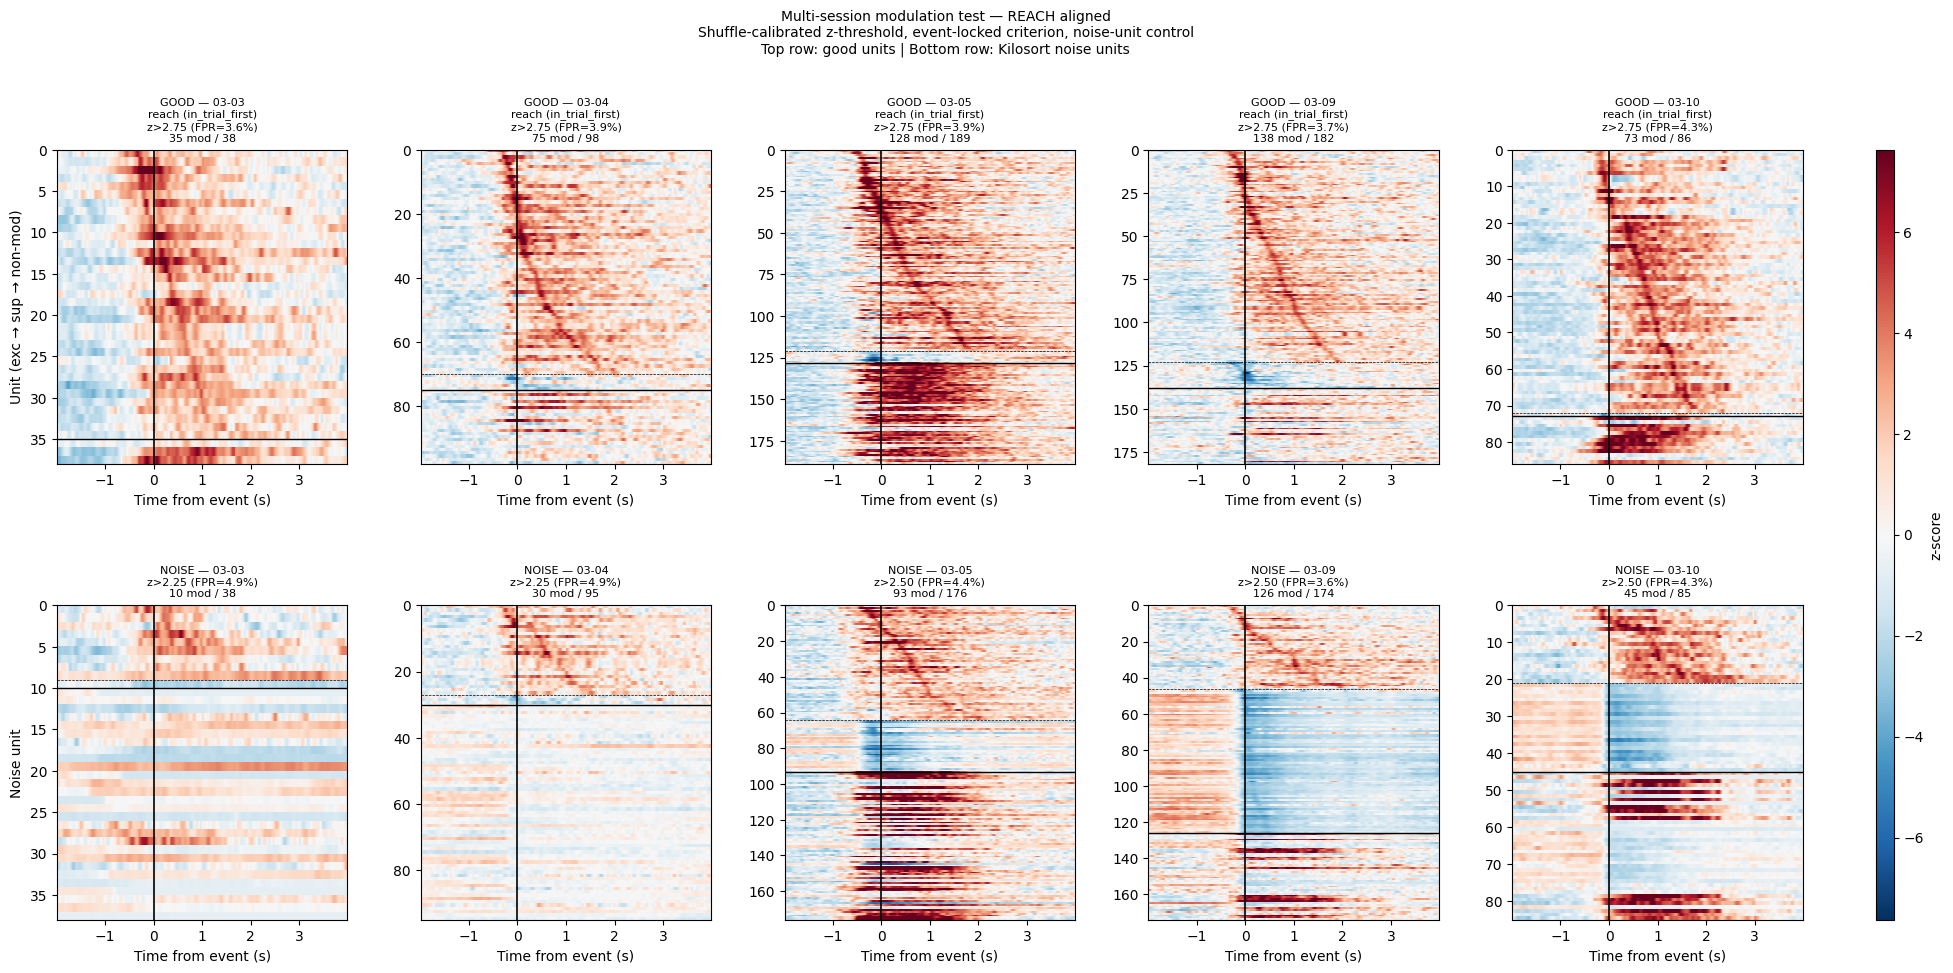


===== SUMMARY TABLE (REACH aligned) =====
Session   N_good  N_eligible   N_mod   Mod%  Z_thr   FPR%  N_noise_mod  NoiseMod%
--------------------------------------------------------------------------------
03-03         38          38      35  92.1%   2.75   3.6%           10      26.3%
03-04         98          98      75  76.5%   2.75   3.9%           30      31.6%
03-05        189         189     128  67.7%   2.75   3.9%           93      52.8%
03-09        182         182     138  75.8%   2.75   3.7%          126      72.4%
03-10         86          86      73  84.9%   2.75   4.3%           45      52.9%

===== CELL M v4 COMPLETE =====



In [1]:
# ============================================================
# CELL M v4 — MULTI-SESSION, DUAL-ALIGNMENT MODULATION TEST
# ============================================================
# Runs the shuffle-calibrated, event-locked modulation test
# (from Cell M v3) across all sessions, for either:
#   "cue"   — aligned to tone onset (pin 4 TTL)
#   "reach" — aligned to DLC bout onsets (in_trial_first)
#
# For each session × alignment:
#   1. Builds a shuffle-calibrated null distribution (N_SHUFFLES
#      random event times) to empirically determine the z-threshold
#      that keeps the false positive rate ≤ TARGET_FPR.
#   2. Tests real events against that threshold with the event-locked
#      criterion (response peak must differ from pre-event baseline
#      by ≥ z_threshold — rejects sustained-background units).
#   3. Runs the SAME test on noise units (Kilosort-labeled "noise")
#      to give you an empirical estimate of your actual false positive
#      rate in this data.
#   4. Saves per-session results and generates a summary figure.
#
# DATA-SHAPING DECISIONS:
#   1. SUBSET: "in_trial_first" for reach alignment — one reach per
#      trial, unambiguous tone pairing, least contamination from
#      retry reaches. This is the most conservative and interpretable
#      choice. Change REACH_SUBSET to "in_trial" for all reaches.
#   2. SHUFFLE RANGE: random events drawn uniformly from
#      [WIN_PRE+1, recording_duration-WIN_POST-1]. This preserves
#      the overall firing rate structure but destroys event-locked
#      timing. It does NOT account for slow drift or non-stationarity
#      within the recording — a unit with a drift trend will have
#      a slightly inflated false positive rate. The noise unit
#      control catches this: if noise units pass at a similar rate
#      to good units, drift/artifacts are likely driving the result.
#   3. MIN_BASELINE_HZ: units firing below this rate are excluded
#      before testing — they don't have enough spikes to detect
#      modulation reliably. This is the only unit-selection step
#      applied here beyond what Cell A already did.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL M v4 — MULTI-SESSION DUAL-ALIGNMENT MODULATION TEST =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
}

ALIGNMENT_MODE  = "reach"     # "cue" or "reach" — run separately for each
REACH_SUBSET    = "in_trial_first"  # only used when ALIGNMENT_MODE == "reach"
TONE_PIN        = 4

WIN_PRE         = 2.0
WIN_POST        = 4.0
RESPONSE_WIN    = (-0.5, 2.0)
BASELINE_WIN    = (-2.0, -0.5)
BIN_SIZE        = 0.020
SMOOTH_SIGMA_BINS = 2
MIN_CONSECUTIVE_MS = 100
MIN_BASELINE_HZ = 1.0
CONSISTENCY_FRAC = 0.30
N_SHUFFLES      = 200
TARGET_FPR      = 0.05
RANDOM_SEED     = 42
RUN_NOISE_CONTROL = True
# ------------------------------------------------------------
# Add to USER EDIT block
MAX_CONSECUTIVE_MS = 1500   # reject responses sustained longer than this —
                             # real reach-locked modulation should peak and
                             # return within ~1-2s; longer = likely artifact.
                             # This is a real criterion that will exclude some
                             # genuine sustained suppression if it exists, but
                             # the tradeoff is worth it given the noise unit
                             # contamination you're seeing from long-duration
                             # artifacts.

edges    = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers  = edges[:-1] + BIN_SIZE / 2
n_bins   = len(centers)
resp_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
base_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

def compute_psth(units, spike_dict, events):
    mat = np.zeros((len(units), len(events), n_bins))
    for u_i, u in enumerate(units):
        spk = spike_dict[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            mat[u_i, e_i] = h / BIN_SIZE
    smooth = gaussian_filter1d(mat, sigma=SMOOTH_SIGMA_BINS, axis=2)
    return smooth, smooth.mean(axis=1)

def is_modulated(z_mat, z_thresh):
    """Event-locked modulation with both minimum AND maximum duration criteria.
    Minimum: at least MIN_CONSECUTIVE_MS of continuous threshold crossing
             (same as before — rejects noise jitter).
    Maximum: no single run longer than MAX_CONSECUTIVE_MS
             (new — rejects sustained artifact signatures).
    Both must be satisfied in the response window."""
    max_consec_bins = int(np.ceil(MAX_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
    out = np.zeros(z_mat.shape[0], dtype=bool)
    for i in range(z_mat.shape[0]):
        z_resp = z_mat[i, resp_mask]
        z_base = z_mat[i, base_mask]

        passed = False
        for arr in (z_resp > z_thresh, z_resp < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d      = np.diff(padded.astype(int))
            starts = np.where(d ==  1)[0]
            ends   = np.where(d == -1)[0]
            run_lengths = ends - starts
            # Must have at least one run ≥ min duration
            if not (run_lengths >= min_consec_bins).any():
                continue
            # Must have NO run > max duration
            # (a run longer than max_consec_bins is artifact, not biology)
            if (run_lengths > max_consec_bins).any():
                continue
            passed = True
            break

        if not passed:
            continue

        # Event-locked check: peak must differ from baseline
        resp_peak = z_resp[np.argmax(np.abs(z_resp))]
        if abs(resp_peak - z_base.mean()) >= z_thresh:
            out[i] = True
    return out

def build_subset_mask(name, bout_trial_id, bout_broke_beam, bout_onset_t):
    if name == "in_trial_first":
        m = np.zeros(len(bout_onset_t), dtype=bool)
        for t_i in np.unique(bout_trial_id):
            if t_i == -1:
                continue
            ii = np.where(bout_trial_id == t_i)[0]
            m[ii[np.argmin(bout_onset_t[ii])]] = True
        return m
    if name == "in_trial":
        return bout_trial_id >= 0
    raise ValueError(f"Unknown subset: {name}")

def run_modulation_test(units, spike_dict, events, rec_dur, rng, label=""):
    n_events = len(events)
    t_min = WIN_PRE + 1.0
    t_max = rec_dur - WIN_POST - 1.0

    print(f"    Building null ({N_SHUFFLES} shuffles, n_events={n_events})...")
    shuffled = np.zeros((N_SHUFFLES, len(units), n_bins))
    for s in range(N_SHUFFLES):
        fake = np.sort(rng.uniform(t_min, t_max, size=n_events))
        _, fake_mean = compute_psth(units, spike_dict, fake)
        shuffled[s] = fake_mean

    null_mean = shuffled.mean(axis=0)
    null_std  = shuffled.std(axis=0)
    null_std  = np.maximum(null_std, null_mean * 0.01 + 0.1)

    # Calibrate z-threshold for TARGET_FPR
    z_grid = np.arange(2.0, 6.01, 0.25)
    fpr    = np.zeros((N_SHUFFLES, len(z_grid)))
    for s in range(N_SHUFFLES):
        z_s = (shuffled[s] - null_mean) / null_std
        for j, thr in enumerate(z_grid):
            fpr[s, j] = is_modulated(z_s, thr).sum() / max(len(units), 1)
    mean_fpr = fpr.mean(axis=0)
    viable   = np.where(mean_fpr <= TARGET_FPR)[0]
    z_chosen = float(z_grid[viable[0]]) if len(viable) else float(z_grid[-1])
    fpr_at_chosen = float(mean_fpr[np.argmin(np.abs(z_grid - z_chosen))])

    # Test real events
    per_trial, real_mean = compute_psth(units, spike_dict, events)
    real_z   = (real_mean - null_mean) / null_std
    mod_init = is_modulated(real_z, z_chosen)

    # Consistency filter
    per_trial_z      = (per_trial - null_mean[:, None, :]) / null_std[:, None, :]
    per_trial_z_resp = per_trial_z[:, :, resp_mask]
    trial_resp       = ((per_trial_z_resp >  z_chosen).any(axis=2) |
                        (per_trial_z_resp < -z_chosen).any(axis=2))
    trial_cons       = trial_resp.mean(axis=1)
    mod_final        = mod_init & (trial_cons >= CONSISTENCY_FRAC)

    z_resp       = real_z[:, resp_mask]
    resp_centers = centers[resp_mask]
    peak_idx     = np.argmax(np.abs(z_resp), axis=1)
    peak_lat     = resp_centers[peak_idx]
    peak_z       = z_resp[np.arange(len(units)), peak_idx]

    n_mod = int(mod_final.sum())
    n_exc = int((peak_z[mod_final] > 0).sum())
    n_sup = int((peak_z[mod_final] < 0).sum())
    print(f"    {label}: z>{z_chosen:.2f} (FPR={fpr_at_chosen*100:.1f}%)  "
          f"modulated={n_mod}/{len(units)} "
          f"(excited={n_exc}, suppressed={n_sup})")

    return {
        "units": units,
        "z_mean": real_z,
        "modulated": mod_final,
        "peak_latency": peak_lat,
        "peak_z": peak_z,
        "trial_consistency": trial_cons,
        "z_threshold": z_chosen,
        "fpr_at_threshold": fpr_at_chosen,
        "n_events": int(n_events),
        "centers": centers,
    }

# ── MAIN LOOP ───────────────────────────────────────────────
all_results = {}   # session_label -> result dict

for label, folder_str in SESSION_FOLDERS.items():
    folder = Path(folder_str)
    print(f"\n===== {label} =====")

    with open(folder / "metadata" / "session.json") as f:
        session_meta = json.load(f)
    rec_dur = session_meta["recording_duration_s"]

    good_units = np.load(folder / "qc" / "good_units.npy")
    spikes_dir = folder / "spikes"
    good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy")
                   for u in good_units}
    unit_rates = np.array([len(good_spikes[int(u)]) / rec_dur
                           for u in good_units])
    eligible = good_units[unit_rates >= MIN_BASELINE_HZ]
    eligible_spikes = {int(u): good_spikes[int(u)] for u in eligible}
    print(f"  Eligible good units: {len(eligible)} / {len(good_units)}")

    # Load noise units
    noise_units, noise_spikes = [], {}
    if RUN_NOISE_CONTROL:
        for f_path in sorted(spikes_dir.glob("noise_unit_*.npy")):
            u = int(f_path.stem.replace("noise_unit_", ""))
            spk = np.load(f_path)
            if len(spk) / rec_dur >= MIN_BASELINE_HZ:
                noise_units.append(u)
                noise_spikes[u] = spk
        print(f"  Eligible noise units: {len(noise_units)}")

    # Get event times for this session
    if ALIGNMENT_MODE == "cue":
        events = np.load(folder / "ttls" / f"TTL_Pin_{TONE_PIN}.npy")
        events = np.sort(events)
        align_label = f"cue (pin {TONE_PIN})"

    elif ALIGNMENT_MODE == "reach":
        bouts = np.load(folder / "peak_detection" / "bouts.npz")
        mask  = build_subset_mask(REACH_SUBSET,
                                  bouts["trial_id"],
                                  bouts["broke_beam"],
                                  bouts["onset_t"])
        events = np.sort(bouts["onset_t"][mask])
        align_label = f"reach ({REACH_SUBSET})"

    else:
        raise ValueError(f"Unknown ALIGNMENT_MODE: {ALIGNMENT_MODE}")

    if len(events) < 10:
        print(f"  Skipping {label}: only {len(events)} events.")
        continue

    print(f"  Events ({align_label}): {len(events)}")

    rng = np.random.default_rng(RANDOM_SEED)

    print(f"  Running on good units...")
    res_good = run_modulation_test(eligible, eligible_spikes, events,
                                   rec_dur, rng, label="good")

    res_noise = None
    if RUN_NOISE_CONTROL and len(noise_units) >= 5:
        print(f"  Running on noise units...")
        rng_n = np.random.default_rng(RANDOM_SEED + 999)
        res_noise = run_modulation_test(
            np.array(noise_units), noise_spikes, events,
            rec_dur, rng_n, label="noise")

    all_results[label] = {
        "good": res_good,
        "noise": res_noise,
        "align_label": align_label,
    }

    # Save per-session results to disk for downstream use
    out_dir = folder / "qc"
    tag = f"v4_{ALIGNMENT_MODE}"
    np.savez(out_dir / f"modulation_{tag}_good_arrays.npz",
             units=res_good["units"],
             z_mean=res_good["z_mean"],
             modulated=res_good["modulated"],
             peak_latency=res_good["peak_latency"],
             peak_z=res_good["peak_z"],
             trial_consistency=res_good["trial_consistency"],
             centers=centers,
             z_threshold=np.array(res_good["z_threshold"]))
    if res_noise is not None:
        np.savez(out_dir / f"modulation_{tag}_noise_arrays.npz",
                 units=res_noise["units"],
                 z_mean=res_noise["z_mean"],
                 modulated=res_noise["modulated"],
                 peak_latency=res_noise["peak_latency"],
                 peak_z=res_noise["peak_z"],
                 centers=centers,
                 z_threshold=np.array(res_noise["z_threshold"]))
    print(f"  Saved → modulation_{tag}_good_arrays.npz")

# ── SUMMARY FIGURE ──────────────────────────────────────────
n_sessions = len(all_results)
n_rows     = 2 if RUN_NOISE_CONTROL else 1

fig = plt.figure(figsize=(4.5 * n_sessions + 1.2, 5 * n_rows))
gs  = fig.add_gridspec(n_rows, n_sessions + 1,
                       width_ratios=[1] * n_sessions + [0.06],
                       wspace=0.3, hspace=0.45)
axes = np.empty((n_rows, n_sessions), dtype=object)
for row in range(n_rows):
    for col in range(n_sessions):
        axes[row, col] = fig.add_subplot(gs[row, col])
cax = fig.add_subplot(gs[:, n_sessions])

all_z_vals = np.concatenate([
    all_results[lbl]["good"]["z_mean"].ravel()
    for lbl in all_results
])
vmax = max(3.0, float(np.percentile(np.abs(all_z_vals), 99)))
im   = None

def sort_order(res):
    mod = res["modulated"]
    pz  = res["peak_z"]
    pl  = res["peak_latency"]
    mod_idx = np.where(mod)[0]
    exc = mod_idx[pz[mod_idx] > 0][np.argsort(pl[mod_idx[pz[mod_idx] > 0]])]
    sup = mod_idx[pz[mod_idx] < 0][np.argsort(pl[mod_idx[pz[mod_idx] < 0]])]
    non = np.where(~mod)[0]
    return np.concatenate([exc, sup, non]), len(exc), len(exc) + len(sup)

for col, lbl in enumerate(all_results):
    res_g = all_results[lbl]["good"]
    res_n = all_results[lbl]["noise"]
    align = all_results[lbl]["align_label"]
    order, n_exc, n_mod = sort_order(res_g)
    n_units = len(res_g["units"])

    ax = axes[0, col]
    im = ax.imshow(res_g["z_mean"][order], aspect="auto",
                   extent=[centers[0], centers[-1], n_units, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.2)
    if n_exc:
        ax.axhline(n_exc, color="black", lw=0.5, ls="--")
    ax.axhline(n_mod, color="black", lw=1.0)
    ax.set_title(f"GOOD — {lbl}\n{align}\n"
                 f"z>{res_g['z_threshold']:.2f} "
                 f"(FPR={res_g['fpr_at_threshold']*100:.1f}%)\n"
                 f"{int(res_g['modulated'].sum())} mod / {n_units}",
                 fontsize=8)
    ax.set_xlabel("Time from event (s)")
    if col == 0:
        ax.set_ylabel("Unit (exc → sup → non-mod)")

    if RUN_NOISE_CONTROL and res_n is not None:
        order_n, n_exc_n, n_mod_n = sort_order(res_n)
        n_noise = len(res_n["units"])
        ax2 = axes[1, col]
        ax2.imshow(res_n["z_mean"][order_n], aspect="auto",
                   extent=[centers[0], centers[-1], n_noise, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
        ax2.axvline(0, color="black", lw=1.2)
        if n_exc_n:
            ax2.axhline(n_exc_n, color="black", lw=0.5, ls="--")
        ax2.axhline(n_mod_n, color="black", lw=1.0)
        ax2.set_title(f"NOISE — {lbl}\n"
                      f"z>{res_n['z_threshold']:.2f} "
                      f"(FPR={res_n['fpr_at_threshold']*100:.1f}%)\n"
                      f"{int(res_n['modulated'].sum())} mod / {n_noise}",
                      fontsize=8)
        ax2.set_xlabel("Time from event (s)")
        if col == 0:
            ax2.set_ylabel("Noise unit")

if im is not None:
    fig.colorbar(im, cax=cax, label="z-score")

plt.suptitle(
    f"Multi-session modulation test — {ALIGNMENT_MODE.upper()} aligned\n"
    f"Shuffle-calibrated z-threshold, event-locked criterion, "
    f"noise-unit control\n"
    f"Top row: good units | Bottom row: Kilosort noise units",
    fontsize=10, y=1.02)
plt.show()

# ── SUMMARY TABLE ────────────────────────────────────────────
print(f"\n===== SUMMARY TABLE ({ALIGNMENT_MODE.upper()} aligned) =====")
print(f"{'Session':<8} {'N_good':>7} {'N_eligible':>11} {'N_mod':>7} "
      f"{'Mod%':>6} {'Z_thr':>6} {'FPR%':>6} "
      f"{'N_noise_mod':>12} {'NoiseMod%':>10}")
print("-" * 80)
for lbl in all_results:
    rg = all_results[lbl]["good"]
    rn = all_results[lbl]["noise"]
    n_el  = len(rg["units"])
    n_mod = int(rg["modulated"].sum())
    if rn is not None:
        nm = int(rn["modulated"].sum())
        np_ = 100 * nm / max(len(rn["units"]), 1)
        noise_str = f"{nm:>12} {np_:>9.1f}%"
    else:
        noise_str = f"{'(n/a)':>12} {'(n/a)':>10}"
    print(f"{lbl:<8} {len(rg['units']):>7} {n_el:>11} {n_mod:>7} "
          f"{100*n_mod/max(n_el,1):>5.1f}% "
          f"{rg['z_threshold']:>6.2f} "
          f"{rg['fpr_at_threshold']*100:>5.1f}% "
          f"{noise_str}")

print(f"\n===== CELL M v4 COMPLETE =====\n")


===== CELL M v4 — MULTI-SESSION DUAL-ALIGNMENT MODULATION TEST =====

===== 03-03 =====
  Eligible good units: 38 / 40
  Eligible noise units: 38
  Events (reach (in_trial)): 106
  Running on good units...
    Building null (200 shuffles, n_events=106)...
    good: z>2.75 (FPR=2.8%)  modulated=30/38 (excited=30, suppressed=0)
  Running on noise units...
    Building null (200 shuffles, n_events=106)...
    noise: z>2.25 (FPR=4.3%)  modulated=9/38 (excited=9, suppressed=0)
  Saved → modulation_v4_reach_good_arrays.npz

===== 03-04 =====
  Eligible good units: 98 / 100
  Eligible noise units: 95
  Events (reach (in_trial)): 111
  Running on good units...
    Building null (200 shuffles, n_events=111)...
    good: z>2.75 (FPR=3.3%)  modulated=74/98 (excited=68, suppressed=6)
  Running on noise units...
    Building null (200 shuffles, n_events=111)...
    noise: z>2.25 (FPR=4.6%)  modulated=31/95 (excited=26, suppressed=5)
  Saved → modulation_v4_reach_good_arrays.npz

===== 03-05 =====


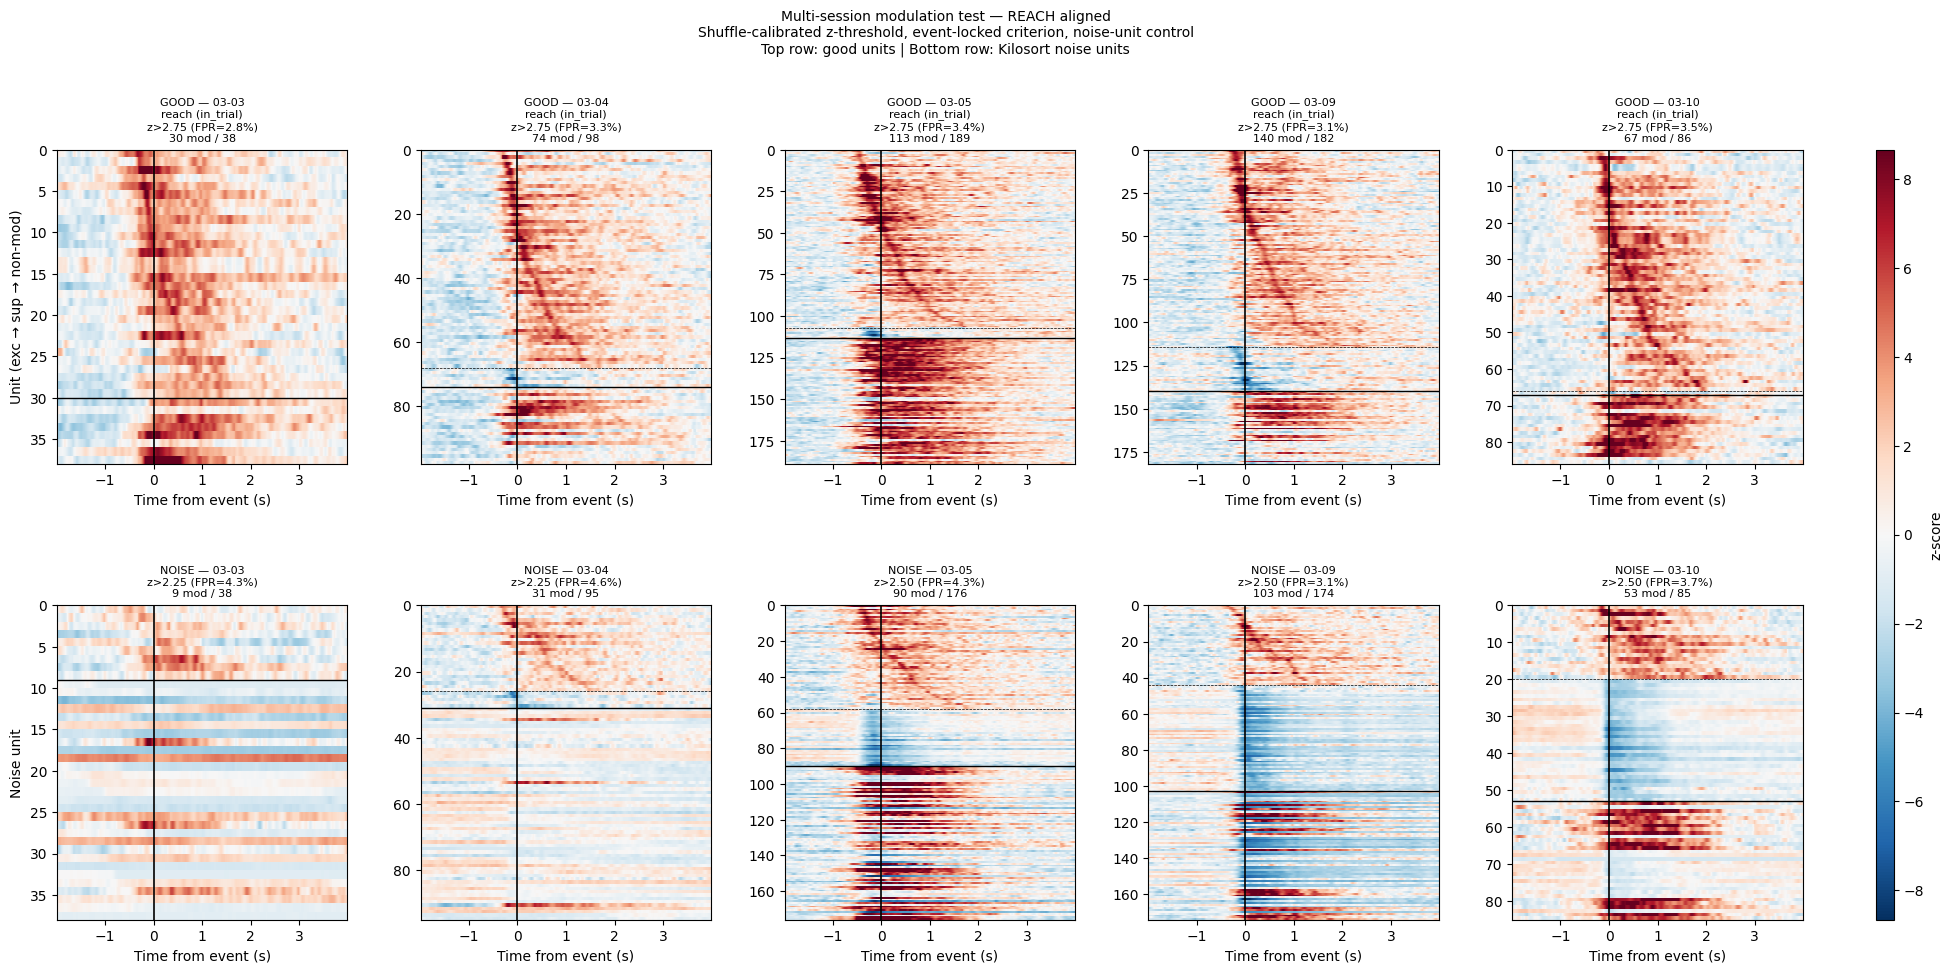


===== SUMMARY TABLE (REACH aligned) =====
Session   N_good  N_eligible   N_mod   Mod%  Z_thr   FPR%  N_noise_mod  NoiseMod%
--------------------------------------------------------------------------------
03-03         38          38      30  78.9%   2.75   2.8%            9      23.7%
03-04         98          98      74  75.5%   2.75   3.3%           31      32.6%
03-05        189         189     113  59.8%   2.75   3.4%           90      51.1%
03-09        182         182     140  76.9%   2.75   3.1%          103      59.2%
03-10         86          86      67  77.9%   2.75   3.5%           53      62.4%

===== CELL M v4 COMPLETE =====



In [2]:
# ============================================================
# CELL M v4 — MULTI-SESSION, DUAL-ALIGNMENT MODULATION TEST
# ============================================================
# Runs the shuffle-calibrated, event-locked modulation test
# (from Cell M v3) across all sessions, for either:
#   "cue"   — aligned to tone onset (pin 4 TTL)
#   "reach" — aligned to DLC bout onsets (in_trial_first)
#
# For each session × alignment:
#   1. Builds a shuffle-calibrated null distribution (N_SHUFFLES
#      random event times) to empirically determine the z-threshold
#      that keeps the false positive rate ≤ TARGET_FPR.
#   2. Tests real events against that threshold with the event-locked
#      criterion (response peak must differ from pre-event baseline
#      by ≥ z_threshold — rejects sustained-background units).
#   3. Runs the SAME test on noise units (Kilosort-labeled "noise")
#      to give you an empirical estimate of your actual false positive
#      rate in this data.
#   4. Saves per-session results and generates a summary figure.
#
# DATA-SHAPING DECISIONS:
#   1. SUBSET: "in_trial_first" for reach alignment — one reach per
#      trial, unambiguous tone pairing, least contamination from
#      retry reaches. This is the most conservative and interpretable
#      choice. Change REACH_SUBSET to "in_trial" for all reaches.
#   2. SHUFFLE RANGE: random events drawn uniformly from
#      [WIN_PRE+1, recording_duration-WIN_POST-1]. This preserves
#      the overall firing rate structure but destroys event-locked
#      timing. It does NOT account for slow drift or non-stationarity
#      within the recording — a unit with a drift trend will have
#      a slightly inflated false positive rate. The noise unit
#      control catches this: if noise units pass at a similar rate
#      to good units, drift/artifacts are likely driving the result.
#   3. MIN_BASELINE_HZ: units firing below this rate are excluded
#      before testing — they don't have enough spikes to detect
#      modulation reliably. This is the only unit-selection step
#      applied here beyond what Cell A already did.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL M v4 — MULTI-SESSION DUAL-ALIGNMENT MODULATION TEST =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
}

ALIGNMENT_MODE  = "reach"     # "cue" or "reach" — run separately for each
REACH_SUBSET    = "in_trial"  # only used when ALIGNMENT_MODE == "reach"
TONE_PIN        = 4

WIN_PRE         = 2.0
WIN_POST        = 4.0
RESPONSE_WIN    = (-0.5, 2.0)
BASELINE_WIN    = (-2.0, -0.5)
BIN_SIZE        = 0.020
SMOOTH_SIGMA_BINS = 2
MIN_CONSECUTIVE_MS = 100
MIN_BASELINE_HZ = 1.0
CONSISTENCY_FRAC = 0.30
N_SHUFFLES      = 200
TARGET_FPR      = 0.05
RANDOM_SEED     = 42
RUN_NOISE_CONTROL = True
# ------------------------------------------------------------
# Add to USER EDIT block
MAX_CONSECUTIVE_MS = 1500   # reject responses sustained longer than this —
                             # real reach-locked modulation should peak and
                             # return within ~1-2s; longer = likely artifact.
                             # This is a real criterion that will exclude some
                             # genuine sustained suppression if it exists, but
                             # the tradeoff is worth it given the noise unit
                             # contamination you're seeing from long-duration
                             # artifacts.

edges    = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers  = edges[:-1] + BIN_SIZE / 2
n_bins   = len(centers)
resp_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
base_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

def compute_psth(units, spike_dict, events):
    mat = np.zeros((len(units), len(events), n_bins))
    for u_i, u in enumerate(units):
        spk = spike_dict[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            mat[u_i, e_i] = h / BIN_SIZE
    smooth = gaussian_filter1d(mat, sigma=SMOOTH_SIGMA_BINS, axis=2)
    return smooth, smooth.mean(axis=1)

def is_modulated(z_mat, z_thresh):
    """Event-locked modulation with both minimum AND maximum duration criteria.
    Minimum: at least MIN_CONSECUTIVE_MS of continuous threshold crossing
             (same as before — rejects noise jitter).
    Maximum: no single run longer than MAX_CONSECUTIVE_MS
             (new — rejects sustained artifact signatures).
    Both must be satisfied in the response window."""
    max_consec_bins = int(np.ceil(MAX_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
    out = np.zeros(z_mat.shape[0], dtype=bool)
    for i in range(z_mat.shape[0]):
        z_resp = z_mat[i, resp_mask]
        z_base = z_mat[i, base_mask]

        passed = False
        for arr in (z_resp > z_thresh, z_resp < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d      = np.diff(padded.astype(int))
            starts = np.where(d ==  1)[0]
            ends   = np.where(d == -1)[0]
            run_lengths = ends - starts
            # Must have at least one run ≥ min duration
            if not (run_lengths >= min_consec_bins).any():
                continue
            # Must have NO run > max duration
            # (a run longer than max_consec_bins is artifact, not biology)
            if (run_lengths > max_consec_bins).any():
                continue
            passed = True
            break

        if not passed:
            continue

        # Event-locked check: peak must differ from baseline
        resp_peak = z_resp[np.argmax(np.abs(z_resp))]
        if abs(resp_peak - z_base.mean()) >= z_thresh:
            out[i] = True
    return out

def build_subset_mask(name, bout_trial_id, bout_broke_beam, bout_onset_t):
    if name == "in_trial_first":
        m = np.zeros(len(bout_onset_t), dtype=bool)
        for t_i in np.unique(bout_trial_id):
            if t_i == -1:
                continue
            ii = np.where(bout_trial_id == t_i)[0]
            m[ii[np.argmin(bout_onset_t[ii])]] = True
        return m
    if name == "in_trial":
        return bout_trial_id >= 0
    raise ValueError(f"Unknown subset: {name}")

def run_modulation_test(units, spike_dict, events, rec_dur, rng, label=""):
    n_events = len(events)
    t_min = WIN_PRE + 1.0
    t_max = rec_dur - WIN_POST - 1.0

    print(f"    Building null ({N_SHUFFLES} shuffles, n_events={n_events})...")
    shuffled = np.zeros((N_SHUFFLES, len(units), n_bins))
    for s in range(N_SHUFFLES):
        fake = np.sort(rng.uniform(t_min, t_max, size=n_events))
        _, fake_mean = compute_psth(units, spike_dict, fake)
        shuffled[s] = fake_mean

    null_mean = shuffled.mean(axis=0)
    null_std  = shuffled.std(axis=0)
    null_std  = np.maximum(null_std, null_mean * 0.01 + 0.1)

    # Calibrate z-threshold for TARGET_FPR
    z_grid = np.arange(2.0, 6.01, 0.25)
    fpr    = np.zeros((N_SHUFFLES, len(z_grid)))
    for s in range(N_SHUFFLES):
        z_s = (shuffled[s] - null_mean) / null_std
        for j, thr in enumerate(z_grid):
            fpr[s, j] = is_modulated(z_s, thr).sum() / max(len(units), 1)
    mean_fpr = fpr.mean(axis=0)
    viable   = np.where(mean_fpr <= TARGET_FPR)[0]
    z_chosen = float(z_grid[viable[0]]) if len(viable) else float(z_grid[-1])
    fpr_at_chosen = float(mean_fpr[np.argmin(np.abs(z_grid - z_chosen))])

    # Test real events
    per_trial, real_mean = compute_psth(units, spike_dict, events)
    real_z   = (real_mean - null_mean) / null_std
    mod_init = is_modulated(real_z, z_chosen)

    # Consistency filter
    per_trial_z      = (per_trial - null_mean[:, None, :]) / null_std[:, None, :]
    per_trial_z_resp = per_trial_z[:, :, resp_mask]
    trial_resp       = ((per_trial_z_resp >  z_chosen).any(axis=2) |
                        (per_trial_z_resp < -z_chosen).any(axis=2))
    trial_cons       = trial_resp.mean(axis=1)
    mod_final        = mod_init & (trial_cons >= CONSISTENCY_FRAC)

    z_resp       = real_z[:, resp_mask]
    resp_centers = centers[resp_mask]
    peak_idx     = np.argmax(np.abs(z_resp), axis=1)
    peak_lat     = resp_centers[peak_idx]
    peak_z       = z_resp[np.arange(len(units)), peak_idx]

    n_mod = int(mod_final.sum())
    n_exc = int((peak_z[mod_final] > 0).sum())
    n_sup = int((peak_z[mod_final] < 0).sum())
    print(f"    {label}: z>{z_chosen:.2f} (FPR={fpr_at_chosen*100:.1f}%)  "
          f"modulated={n_mod}/{len(units)} "
          f"(excited={n_exc}, suppressed={n_sup})")

    return {
        "units": units,
        "z_mean": real_z,
        "modulated": mod_final,
        "peak_latency": peak_lat,
        "peak_z": peak_z,
        "trial_consistency": trial_cons,
        "z_threshold": z_chosen,
        "fpr_at_threshold": fpr_at_chosen,
        "n_events": int(n_events),
        "centers": centers,
    }

# ── MAIN LOOP ───────────────────────────────────────────────
all_results = {}   # session_label -> result dict

for label, folder_str in SESSION_FOLDERS.items():
    folder = Path(folder_str)
    print(f"\n===== {label} =====")

    with open(folder / "metadata" / "session.json") as f:
        session_meta = json.load(f)
    rec_dur = session_meta["recording_duration_s"]

    good_units = np.load(folder / "qc" / "good_units.npy")
    spikes_dir = folder / "spikes"
    good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy")
                   for u in good_units}
    unit_rates = np.array([len(good_spikes[int(u)]) / rec_dur
                           for u in good_units])
    eligible = good_units[unit_rates >= MIN_BASELINE_HZ]
    eligible_spikes = {int(u): good_spikes[int(u)] for u in eligible}
    print(f"  Eligible good units: {len(eligible)} / {len(good_units)}")

    # Load noise units
    noise_units, noise_spikes = [], {}
    if RUN_NOISE_CONTROL:
        for f_path in sorted(spikes_dir.glob("noise_unit_*.npy")):
            u = int(f_path.stem.replace("noise_unit_", ""))
            spk = np.load(f_path)
            if len(spk) / rec_dur >= MIN_BASELINE_HZ:
                noise_units.append(u)
                noise_spikes[u] = spk
        print(f"  Eligible noise units: {len(noise_units)}")

    # Get event times for this session
    if ALIGNMENT_MODE == "cue":
        events = np.load(folder / "ttls" / f"TTL_Pin_{TONE_PIN}.npy")
        events = np.sort(events)
        align_label = f"cue (pin {TONE_PIN})"

    elif ALIGNMENT_MODE == "reach":
        bouts = np.load(folder / "peak_detection" / "bouts.npz")
        mask  = build_subset_mask(REACH_SUBSET,
                                  bouts["trial_id"],
                                  bouts["broke_beam"],
                                  bouts["onset_t"])
        events = np.sort(bouts["onset_t"][mask])
        align_label = f"reach ({REACH_SUBSET})"

    else:
        raise ValueError(f"Unknown ALIGNMENT_MODE: {ALIGNMENT_MODE}")

    if len(events) < 10:
        print(f"  Skipping {label}: only {len(events)} events.")
        continue

    print(f"  Events ({align_label}): {len(events)}")

    rng = np.random.default_rng(RANDOM_SEED)

    print(f"  Running on good units...")
    res_good = run_modulation_test(eligible, eligible_spikes, events,
                                   rec_dur, rng, label="good")

    res_noise = None
    if RUN_NOISE_CONTROL and len(noise_units) >= 5:
        print(f"  Running on noise units...")
        rng_n = np.random.default_rng(RANDOM_SEED + 999)
        res_noise = run_modulation_test(
            np.array(noise_units), noise_spikes, events,
            rec_dur, rng_n, label="noise")

    all_results[label] = {
        "good": res_good,
        "noise": res_noise,
        "align_label": align_label,
    }

    # Save per-session results to disk for downstream use
    out_dir = folder / "qc"
    tag = f"v4_{ALIGNMENT_MODE}"
    np.savez(out_dir / f"modulation_{tag}_good_arrays.npz",
             units=res_good["units"],
             z_mean=res_good["z_mean"],
             modulated=res_good["modulated"],
             peak_latency=res_good["peak_latency"],
             peak_z=res_good["peak_z"],
             trial_consistency=res_good["trial_consistency"],
             centers=centers,
             z_threshold=np.array(res_good["z_threshold"]))
    if res_noise is not None:
        np.savez(out_dir / f"modulation_{tag}_noise_arrays.npz",
                 units=res_noise["units"],
                 z_mean=res_noise["z_mean"],
                 modulated=res_noise["modulated"],
                 peak_latency=res_noise["peak_latency"],
                 peak_z=res_noise["peak_z"],
                 centers=centers,
                 z_threshold=np.array(res_noise["z_threshold"]))
    print(f"  Saved → modulation_{tag}_good_arrays.npz")

# ── SUMMARY FIGURE ──────────────────────────────────────────
n_sessions = len(all_results)
n_rows     = 2 if RUN_NOISE_CONTROL else 1

fig = plt.figure(figsize=(4.5 * n_sessions + 1.2, 5 * n_rows))
gs  = fig.add_gridspec(n_rows, n_sessions + 1,
                       width_ratios=[1] * n_sessions + [0.06],
                       wspace=0.3, hspace=0.45)
axes = np.empty((n_rows, n_sessions), dtype=object)
for row in range(n_rows):
    for col in range(n_sessions):
        axes[row, col] = fig.add_subplot(gs[row, col])
cax = fig.add_subplot(gs[:, n_sessions])

all_z_vals = np.concatenate([
    all_results[lbl]["good"]["z_mean"].ravel()
    for lbl in all_results
])
vmax = max(3.0, float(np.percentile(np.abs(all_z_vals), 99)))
im   = None

def sort_order(res):
    mod = res["modulated"]
    pz  = res["peak_z"]
    pl  = res["peak_latency"]
    mod_idx = np.where(mod)[0]
    exc = mod_idx[pz[mod_idx] > 0][np.argsort(pl[mod_idx[pz[mod_idx] > 0]])]
    sup = mod_idx[pz[mod_idx] < 0][np.argsort(pl[mod_idx[pz[mod_idx] < 0]])]
    non = np.where(~mod)[0]
    return np.concatenate([exc, sup, non]), len(exc), len(exc) + len(sup)

for col, lbl in enumerate(all_results):
    res_g = all_results[lbl]["good"]
    res_n = all_results[lbl]["noise"]
    align = all_results[lbl]["align_label"]
    order, n_exc, n_mod = sort_order(res_g)
    n_units = len(res_g["units"])

    ax = axes[0, col]
    im = ax.imshow(res_g["z_mean"][order], aspect="auto",
                   extent=[centers[0], centers[-1], n_units, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.2)
    if n_exc:
        ax.axhline(n_exc, color="black", lw=0.5, ls="--")
    ax.axhline(n_mod, color="black", lw=1.0)
    ax.set_title(f"GOOD — {lbl}\n{align}\n"
                 f"z>{res_g['z_threshold']:.2f} "
                 f"(FPR={res_g['fpr_at_threshold']*100:.1f}%)\n"
                 f"{int(res_g['modulated'].sum())} mod / {n_units}",
                 fontsize=8)
    ax.set_xlabel("Time from event (s)")
    if col == 0:
        ax.set_ylabel("Unit (exc → sup → non-mod)")

    if RUN_NOISE_CONTROL and res_n is not None:
        order_n, n_exc_n, n_mod_n = sort_order(res_n)
        n_noise = len(res_n["units"])
        ax2 = axes[1, col]
        ax2.imshow(res_n["z_mean"][order_n], aspect="auto",
                   extent=[centers[0], centers[-1], n_noise, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
        ax2.axvline(0, color="black", lw=1.2)
        if n_exc_n:
            ax2.axhline(n_exc_n, color="black", lw=0.5, ls="--")
        ax2.axhline(n_mod_n, color="black", lw=1.0)
        ax2.set_title(f"NOISE — {lbl}\n"
                      f"z>{res_n['z_threshold']:.2f} "
                      f"(FPR={res_n['fpr_at_threshold']*100:.1f}%)\n"
                      f"{int(res_n['modulated'].sum())} mod / {n_noise}",
                      fontsize=8)
        ax2.set_xlabel("Time from event (s)")
        if col == 0:
            ax2.set_ylabel("Noise unit")

if im is not None:
    fig.colorbar(im, cax=cax, label="z-score")

plt.suptitle(
    f"Multi-session modulation test — {ALIGNMENT_MODE.upper()} aligned\n"
    f"Shuffle-calibrated z-threshold, event-locked criterion, "
    f"noise-unit control\n"
    f"Top row: good units | Bottom row: Kilosort noise units",
    fontsize=10, y=1.02)
plt.show()

# ── SUMMARY TABLE ────────────────────────────────────────────
print(f"\n===== SUMMARY TABLE ({ALIGNMENT_MODE.upper()} aligned) =====")
print(f"{'Session':<8} {'N_good':>7} {'N_eligible':>11} {'N_mod':>7} "
      f"{'Mod%':>6} {'Z_thr':>6} {'FPR%':>6} "
      f"{'N_noise_mod':>12} {'NoiseMod%':>10}")
print("-" * 80)
for lbl in all_results:
    rg = all_results[lbl]["good"]
    rn = all_results[lbl]["noise"]
    n_el  = len(rg["units"])
    n_mod = int(rg["modulated"].sum())
    if rn is not None:
        nm = int(rn["modulated"].sum())
        np_ = 100 * nm / max(len(rn["units"]), 1)
        noise_str = f"{nm:>12} {np_:>9.1f}%"
    else:
        noise_str = f"{'(n/a)':>12} {'(n/a)':>10}"
    print(f"{lbl:<8} {len(rg['units']):>7} {n_el:>11} {n_mod:>7} "
          f"{100*n_mod/max(n_el,1):>5.1f}% "
          f"{rg['z_threshold']:>6.2f} "
          f"{rg['fpr_at_threshold']*100:>5.1f}% "
          f"{noise_str}")

print(f"\n===== CELL M v4 COMPLETE =====\n")


===== CELL M v4 — MULTI-SESSION DUAL-ALIGNMENT MODULATION TEST =====

===== 03-03 =====
  Eligible good units: 38 / 40
  Eligible noise units: 38
  Events (cue (pin 4)): 55
  Running on good units...
    Building null (200 shuffles, n_events=55)...
    good: z>2.75 (FPR=3.4%)  modulated=10/38 (excited=10, suppressed=0)
  Running on noise units...
    Building null (200 shuffles, n_events=55)...
    noise: z>2.25 (FPR=4.7%)  modulated=17/38 (excited=12, suppressed=5)
  Saved → modulation_v4_cue_good_arrays.npz

===== 03-04 =====
  Eligible good units: 98 / 100
  Eligible noise units: 95
  Events (cue (pin 4)): 71
  Running on good units...
    Building null (200 shuffles, n_events=71)...
    good: z>2.75 (FPR=3.5%)  modulated=22/98 (excited=19, suppressed=3)
  Running on noise units...
    Building null (200 shuffles, n_events=71)...
    noise: z>2.25 (FPR=4.9%)  modulated=37/95 (excited=10, suppressed=27)
  Saved → modulation_v4_cue_good_arrays.npz

===== 03-05 =====
  Eligible good u

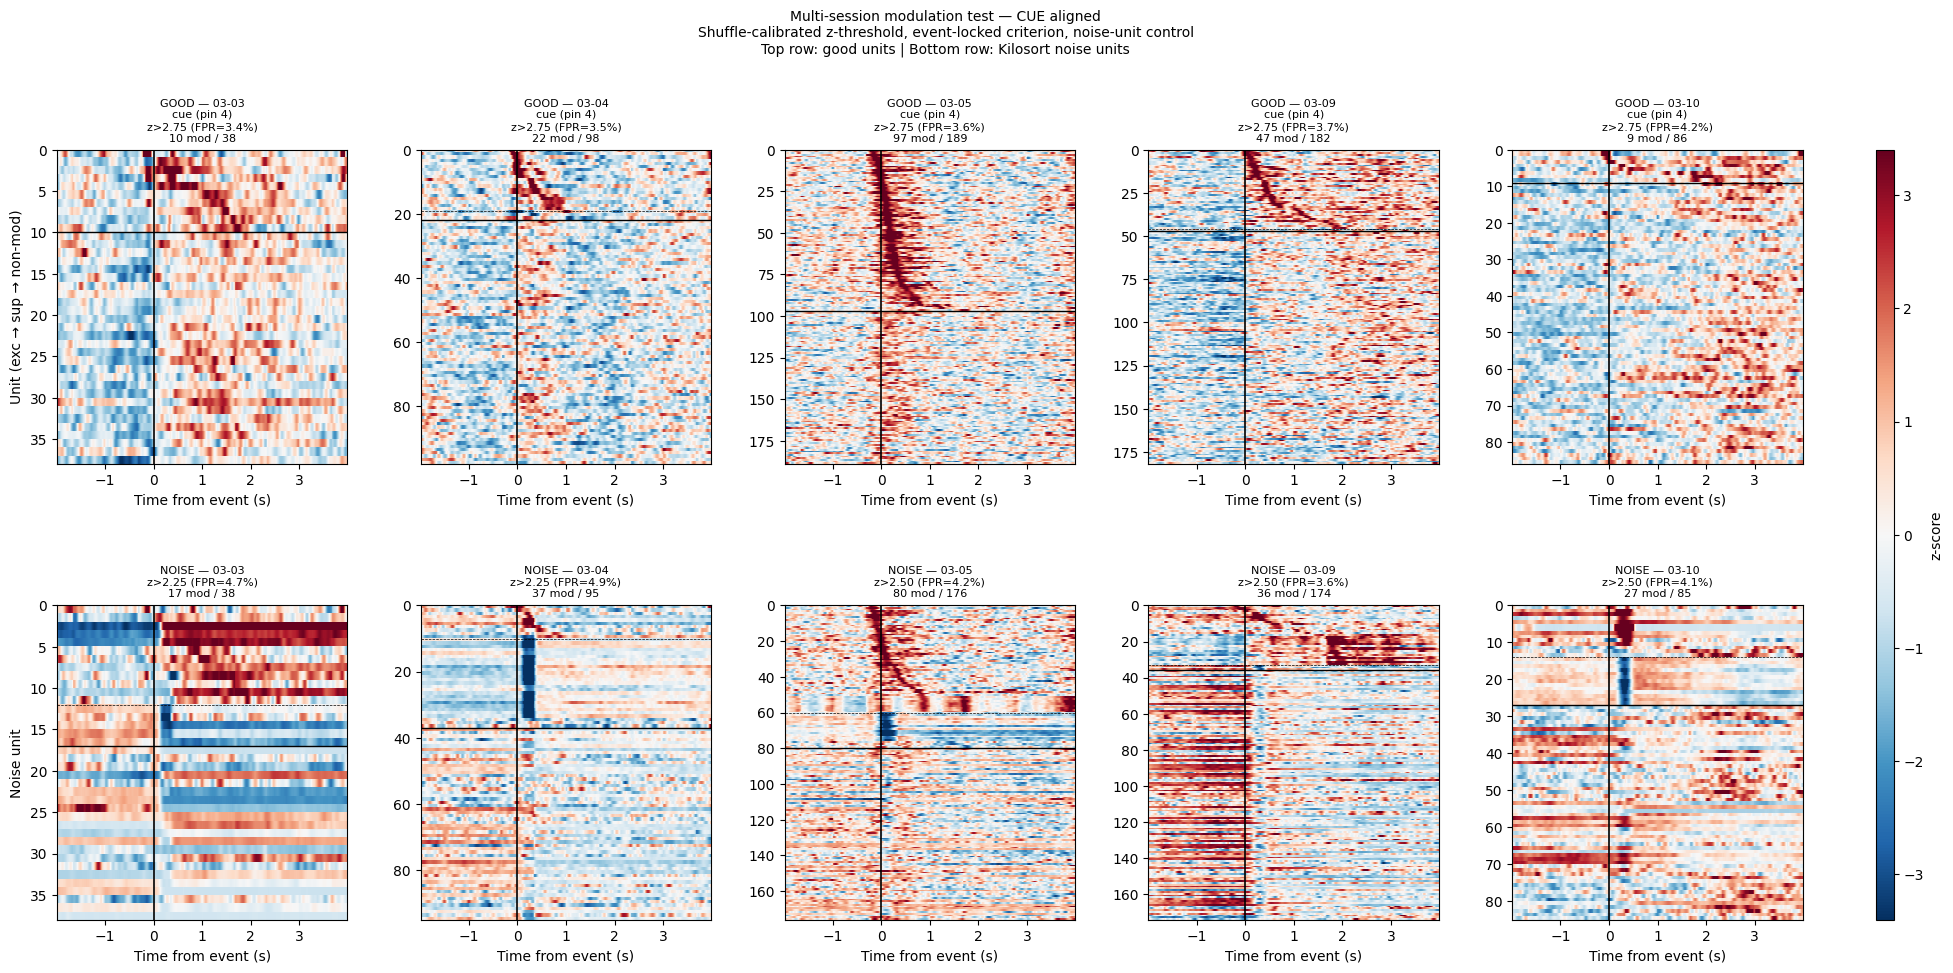


===== SUMMARY TABLE (CUE aligned) =====
Session   N_good  N_eligible   N_mod   Mod%  Z_thr   FPR%  N_noise_mod  NoiseMod%
--------------------------------------------------------------------------------
03-03         38          38      10  26.3%   2.75   3.4%           17      44.7%
03-04         98          98      22  22.4%   2.75   3.5%           37      38.9%
03-05        189         189      97  51.3%   2.75   3.6%           80      45.5%
03-09        182         182      47  25.8%   2.75   3.7%           36      20.7%
03-10         86          86       9  10.5%   2.75   4.2%           27      31.8%

===== CELL M v4 COMPLETE =====



In [7]:
# ============================================================
# CELL M v4 — MULTI-SESSION, DUAL-ALIGNMENT MODULATION TEST
# ============================================================
# Runs the shuffle-calibrated, event-locked modulation test
# (from Cell M v3) across all sessions, for either:
#   "cue"   — aligned to tone onset (pin 4 TTL)
#   "reach" — aligned to DLC bout onsets (in_trial_first)
#
# For each session × alignment:
#   1. Builds a shuffle-calibrated null distribution (N_SHUFFLES
#      random event times) to empirically determine the z-threshold
#      that keeps the false positive rate ≤ TARGET_FPR.
#   2. Tests real events against that threshold with the event-locked
#      criterion (response peak must differ from pre-event baseline
#      by ≥ z_threshold — rejects sustained-background units).
#   3. Runs the SAME test on noise units (Kilosort-labeled "noise")
#      to give you an empirical estimate of your actual false positive
#      rate in this data.
#   4. Saves per-session results and generates a summary figure.
#
# DATA-SHAPING DECISIONS:
#   1. SUBSET: "in_trial_first" for reach alignment — one reach per
#      trial, unambiguous tone pairing, least contamination from
#      retry reaches. This is the most conservative and interpretable
#      choice. Change REACH_SUBSET to "in_trial" for all reaches.
#   2. SHUFFLE RANGE: random events drawn uniformly from
#      [WIN_PRE+1, recording_duration-WIN_POST-1]. This preserves
#      the overall firing rate structure but destroys event-locked
#      timing. It does NOT account for slow drift or non-stationarity
#      within the recording — a unit with a drift trend will have
#      a slightly inflated false positive rate. The noise unit
#      control catches this: if noise units pass at a similar rate
#      to good units, drift/artifacts are likely driving the result.
#   3. MIN_BASELINE_HZ: units firing below this rate are excluded
#      before testing — they don't have enough spikes to detect
#      modulation reliably. This is the only unit-selection step
#      applied here beyond what Cell A already did.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL M v4 — MULTI-SESSION DUAL-ALIGNMENT MODULATION TEST =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
}

ALIGNMENT_MODE  = "cue"     # "cue" or "reach" — run separately for each
REACH_SUBSET    = "in_trial_first"  # only used when ALIGNMENT_MODE == "reach"
TONE_PIN        = 4

WIN_PRE         = 2.0
WIN_POST        = 4.0
RESPONSE_WIN    = (-0.5, 2.0)
BASELINE_WIN    = (-2.0, -0.5)
BIN_SIZE        = 0.020
SMOOTH_SIGMA_BINS = 2
MIN_CONSECUTIVE_MS = 100
MIN_BASELINE_HZ = 1.0
CONSISTENCY_FRAC = 0.30
N_SHUFFLES      = 200
TARGET_FPR      = 0.05
RANDOM_SEED     = 42
RUN_NOISE_CONTROL = True
# ------------------------------------------------------------

edges    = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers  = edges[:-1] + BIN_SIZE / 2
n_bins   = len(centers)
resp_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
base_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

def compute_psth(units, spike_dict, events):
    mat = np.zeros((len(units), len(events), n_bins))
    for u_i, u in enumerate(units):
        spk = spike_dict[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            mat[u_i, e_i] = h / BIN_SIZE
    smooth = gaussian_filter1d(mat, sigma=SMOOTH_SIGMA_BINS, axis=2)
    return smooth, smooth.mean(axis=1)

def is_modulated(z_mat, z_thresh):
    out = np.zeros(z_mat.shape[0], dtype=bool)
    for i in range(z_mat.shape[0]):
        z_resp = z_mat[i, resp_mask]
        z_base = z_mat[i, base_mask]
        passed = False
        for arr in (z_resp > z_thresh, z_resp < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d = np.diff(padded.astype(int))
            starts = np.where(d == 1)[0]
            ends   = np.where(d == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                passed = True
                break
        if not passed:
            continue
        resp_peak = z_resp[np.argmax(np.abs(z_resp))]
        if abs(resp_peak - z_base.mean()) >= z_thresh:
            out[i] = True
    return out

def build_subset_mask(name, bout_trial_id, bout_broke_beam, bout_onset_t):
    if name == "in_trial_first":
        m = np.zeros(len(bout_onset_t), dtype=bool)
        for t_i in np.unique(bout_trial_id):
            if t_i == -1:
                continue
            ii = np.where(bout_trial_id == t_i)[0]
            m[ii[np.argmin(bout_onset_t[ii])]] = True
        return m
    if name == "in_trial":
        return bout_trial_id >= 0
    raise ValueError(f"Unknown subset: {name}")

def run_modulation_test(units, spike_dict, events, rec_dur, rng, label=""):
    n_events = len(events)
    t_min = WIN_PRE + 1.0
    t_max = rec_dur - WIN_POST - 1.0

    print(f"    Building null ({N_SHUFFLES} shuffles, n_events={n_events})...")
    shuffled = np.zeros((N_SHUFFLES, len(units), n_bins))
    for s in range(N_SHUFFLES):
        fake = np.sort(rng.uniform(t_min, t_max, size=n_events))
        _, fake_mean = compute_psth(units, spike_dict, fake)
        shuffled[s] = fake_mean

    null_mean = shuffled.mean(axis=0)
    null_std  = shuffled.std(axis=0)
    null_std  = np.maximum(null_std, null_mean * 0.01 + 0.1)

    # Calibrate z-threshold for TARGET_FPR
    z_grid = np.arange(2.0, 6.01, 0.25)
    fpr    = np.zeros((N_SHUFFLES, len(z_grid)))
    for s in range(N_SHUFFLES):
        z_s = (shuffled[s] - null_mean) / null_std
        for j, thr in enumerate(z_grid):
            fpr[s, j] = is_modulated(z_s, thr).sum() / max(len(units), 1)
    mean_fpr = fpr.mean(axis=0)
    viable   = np.where(mean_fpr <= TARGET_FPR)[0]
    z_chosen = float(z_grid[viable[0]]) if len(viable) else float(z_grid[-1])
    fpr_at_chosen = float(mean_fpr[np.argmin(np.abs(z_grid - z_chosen))])

    # Test real events
    per_trial, real_mean = compute_psth(units, spike_dict, events)
    real_z   = (real_mean - null_mean) / null_std
    mod_init = is_modulated(real_z, z_chosen)

    # Consistency filter
    per_trial_z      = (per_trial - null_mean[:, None, :]) / null_std[:, None, :]
    per_trial_z_resp = per_trial_z[:, :, resp_mask]
    trial_resp       = ((per_trial_z_resp >  z_chosen).any(axis=2) |
                        (per_trial_z_resp < -z_chosen).any(axis=2))
    trial_cons       = trial_resp.mean(axis=1)
    mod_final        = mod_init & (trial_cons >= CONSISTENCY_FRAC)

    z_resp       = real_z[:, resp_mask]
    resp_centers = centers[resp_mask]
    peak_idx     = np.argmax(np.abs(z_resp), axis=1)
    peak_lat     = resp_centers[peak_idx]
    peak_z       = z_resp[np.arange(len(units)), peak_idx]

    n_mod = int(mod_final.sum())
    n_exc = int((peak_z[mod_final] > 0).sum())
    n_sup = int((peak_z[mod_final] < 0).sum())
    print(f"    {label}: z>{z_chosen:.2f} (FPR={fpr_at_chosen*100:.1f}%)  "
          f"modulated={n_mod}/{len(units)} "
          f"(excited={n_exc}, suppressed={n_sup})")

    return {
        "units": units,
        "z_mean": real_z,
        "modulated": mod_final,
        "peak_latency": peak_lat,
        "peak_z": peak_z,
        "trial_consistency": trial_cons,
        "z_threshold": z_chosen,
        "fpr_at_threshold": fpr_at_chosen,
        "n_events": int(n_events),
        "centers": centers,
    }

# ── MAIN LOOP ───────────────────────────────────────────────
all_results = {}   # session_label -> result dict

for label, folder_str in SESSION_FOLDERS.items():
    folder = Path(folder_str)
    print(f"\n===== {label} =====")

    with open(folder / "metadata" / "session.json") as f:
        session_meta = json.load(f)
    rec_dur = session_meta["recording_duration_s"]

    good_units = np.load(folder / "qc" / "good_units.npy")
    spikes_dir = folder / "spikes"
    good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy")
                   for u in good_units}
    unit_rates = np.array([len(good_spikes[int(u)]) / rec_dur
                           for u in good_units])
    eligible = good_units[unit_rates >= MIN_BASELINE_HZ]
    eligible_spikes = {int(u): good_spikes[int(u)] for u in eligible}
    print(f"  Eligible good units: {len(eligible)} / {len(good_units)}")

    # Load noise units
    noise_units, noise_spikes = [], {}
    if RUN_NOISE_CONTROL:
        for f_path in sorted(spikes_dir.glob("noise_unit_*.npy")):
            u = int(f_path.stem.replace("noise_unit_", ""))
            spk = np.load(f_path)
            if len(spk) / rec_dur >= MIN_BASELINE_HZ:
                noise_units.append(u)
                noise_spikes[u] = spk
        print(f"  Eligible noise units: {len(noise_units)}")

    # Get event times for this session
    if ALIGNMENT_MODE == "cue":
        events = np.load(folder / "ttls" / f"TTL_Pin_{TONE_PIN}.npy")
        events = np.sort(events)
        align_label = f"cue (pin {TONE_PIN})"

    elif ALIGNMENT_MODE == "reach":
        bouts = np.load(folder / "peak_detection" / "bouts.npz")
        mask  = build_subset_mask(REACH_SUBSET,
                                  bouts["trial_id"],
                                  bouts["broke_beam"],
                                  bouts["onset_t"])
        events = np.sort(bouts["onset_t"][mask])
        align_label = f"reach ({REACH_SUBSET})"

    else:
        raise ValueError(f"Unknown ALIGNMENT_MODE: {ALIGNMENT_MODE}")

    if len(events) < 10:
        print(f"  Skipping {label}: only {len(events)} events.")
        continue

    print(f"  Events ({align_label}): {len(events)}")

    rng = np.random.default_rng(RANDOM_SEED)

    print(f"  Running on good units...")
    res_good = run_modulation_test(eligible, eligible_spikes, events,
                                   rec_dur, rng, label="good")

    res_noise = None
    if RUN_NOISE_CONTROL and len(noise_units) >= 5:
        print(f"  Running on noise units...")
        rng_n = np.random.default_rng(RANDOM_SEED + 999)
        res_noise = run_modulation_test(
            np.array(noise_units), noise_spikes, events,
            rec_dur, rng_n, label="noise")

    all_results[label] = {
        "good": res_good,
        "noise": res_noise,
        "align_label": align_label,
    }

    # Save per-session results to disk for downstream use
    out_dir = folder / "qc"
    tag = f"v4_{ALIGNMENT_MODE}"
    np.savez(out_dir / f"modulation_{tag}_good_arrays.npz",
             units=res_good["units"],
             z_mean=res_good["z_mean"],
             modulated=res_good["modulated"],
             peak_latency=res_good["peak_latency"],
             peak_z=res_good["peak_z"],
             trial_consistency=res_good["trial_consistency"],
             centers=centers,
             z_threshold=np.array(res_good["z_threshold"]))
    if res_noise is not None:
        np.savez(out_dir / f"modulation_{tag}_noise_arrays.npz",
                 units=res_noise["units"],
                 z_mean=res_noise["z_mean"],
                 modulated=res_noise["modulated"],
                 peak_latency=res_noise["peak_latency"],
                 peak_z=res_noise["peak_z"],
                 centers=centers,
                 z_threshold=np.array(res_noise["z_threshold"]))
    print(f"  Saved → modulation_{tag}_good_arrays.npz")

# ── SUMMARY FIGURE ──────────────────────────────────────────
n_sessions = len(all_results)
n_rows     = 2 if RUN_NOISE_CONTROL else 1

fig = plt.figure(figsize=(4.5 * n_sessions + 1.2, 5 * n_rows))
gs  = fig.add_gridspec(n_rows, n_sessions + 1,
                       width_ratios=[1] * n_sessions + [0.06],
                       wspace=0.3, hspace=0.45)
axes = np.empty((n_rows, n_sessions), dtype=object)
for row in range(n_rows):
    for col in range(n_sessions):
        axes[row, col] = fig.add_subplot(gs[row, col])
cax = fig.add_subplot(gs[:, n_sessions])

all_z_vals = np.concatenate([
    all_results[lbl]["good"]["z_mean"].ravel()
    for lbl in all_results
])
vmax = max(3.0, float(np.percentile(np.abs(all_z_vals), 99)))
im   = None

def sort_order(res):
    mod = res["modulated"]
    pz  = res["peak_z"]
    pl  = res["peak_latency"]
    mod_idx = np.where(mod)[0]
    exc = mod_idx[pz[mod_idx] > 0][np.argsort(pl[mod_idx[pz[mod_idx] > 0]])]
    sup = mod_idx[pz[mod_idx] < 0][np.argsort(pl[mod_idx[pz[mod_idx] < 0]])]
    non = np.where(~mod)[0]
    return np.concatenate([exc, sup, non]), len(exc), len(exc) + len(sup)

for col, lbl in enumerate(all_results):
    res_g = all_results[lbl]["good"]
    res_n = all_results[lbl]["noise"]
    align = all_results[lbl]["align_label"]
    order, n_exc, n_mod = sort_order(res_g)
    n_units = len(res_g["units"])

    ax = axes[0, col]
    im = ax.imshow(res_g["z_mean"][order], aspect="auto",
                   extent=[centers[0], centers[-1], n_units, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.2)
    if n_exc:
        ax.axhline(n_exc, color="black", lw=0.5, ls="--")
    ax.axhline(n_mod, color="black", lw=1.0)
    ax.set_title(f"GOOD — {lbl}\n{align}\n"
                 f"z>{res_g['z_threshold']:.2f} "
                 f"(FPR={res_g['fpr_at_threshold']*100:.1f}%)\n"
                 f"{int(res_g['modulated'].sum())} mod / {n_units}",
                 fontsize=8)
    ax.set_xlabel("Time from event (s)")
    if col == 0:
        ax.set_ylabel("Unit (exc → sup → non-mod)")

    if RUN_NOISE_CONTROL and res_n is not None:
        order_n, n_exc_n, n_mod_n = sort_order(res_n)
        n_noise = len(res_n["units"])
        ax2 = axes[1, col]
        ax2.imshow(res_n["z_mean"][order_n], aspect="auto",
                   extent=[centers[0], centers[-1], n_noise, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
        ax2.axvline(0, color="black", lw=1.2)
        if n_exc_n:
            ax2.axhline(n_exc_n, color="black", lw=0.5, ls="--")
        ax2.axhline(n_mod_n, color="black", lw=1.0)
        ax2.set_title(f"NOISE — {lbl}\n"
                      f"z>{res_n['z_threshold']:.2f} "
                      f"(FPR={res_n['fpr_at_threshold']*100:.1f}%)\n"
                      f"{int(res_n['modulated'].sum())} mod / {n_noise}",
                      fontsize=8)
        ax2.set_xlabel("Time from event (s)")
        if col == 0:
            ax2.set_ylabel("Noise unit")

if im is not None:
    fig.colorbar(im, cax=cax, label="z-score")

plt.suptitle(
    f"Multi-session modulation test — {ALIGNMENT_MODE.upper()} aligned\n"
    f"Shuffle-calibrated z-threshold, event-locked criterion, "
    f"noise-unit control\n"
    f"Top row: good units | Bottom row: Kilosort noise units",
    fontsize=10, y=1.02)
plt.show()

# ── SUMMARY TABLE ────────────────────────────────────────────
print(f"\n===== SUMMARY TABLE ({ALIGNMENT_MODE.upper()} aligned) =====")
print(f"{'Session':<8} {'N_good':>7} {'N_eligible':>11} {'N_mod':>7} "
      f"{'Mod%':>6} {'Z_thr':>6} {'FPR%':>6} "
      f"{'N_noise_mod':>12} {'NoiseMod%':>10}")
print("-" * 80)
for lbl in all_results:
    rg = all_results[lbl]["good"]
    rn = all_results[lbl]["noise"]
    n_el  = len(rg["units"])
    n_mod = int(rg["modulated"].sum())
    if rn is not None:
        nm = int(rn["modulated"].sum())
        np_ = 100 * nm / max(len(rn["units"]), 1)
        noise_str = f"{nm:>12} {np_:>9.1f}%"
    else:
        noise_str = f"{'(n/a)':>12} {'(n/a)':>10}"
    print(f"{lbl:<8} {len(rg['units']):>7} {n_el:>11} {n_mod:>7} "
          f"{100*n_mod/max(n_el,1):>5.1f}% "
          f"{rg['z_threshold']:>6.2f} "
          f"{rg['fpr_at_threshold']*100:>5.1f}% "
          f"{noise_str}")

print(f"\n===== CELL M v4 COMPLETE =====\n")